<a href="https://colab.research.google.com/github/Dc-qwerty/NSE/blob/charity/NSE_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Business Problem

Retail investors on the NSE often face information asymmetry, high volatility, and liquidity challenges when deciding at what price to place buy (bid) or sell (offer) orders. Many rely on gut feel, broker advice, or simple charts, leading to suboptimal entries/exits, slippage, missed opportunities, or unnecessary losses.
The system aims to reduce this gap by using historical daily data (2022–2025) to forecast near-term price behavior (e.g., next-day close, Day Low, or Day High). This helps investors set smarter limit orders, for example, bidding near a predicted Day Low or offering near a predicted Day High, while incorporating volume and market context.


### Business Understanding

Develop a transparent, backtestable short-horizon price prediction system that forecasts next-day Day Low, Day High, and Day Price using 2022–2025 daily data. The system will help investors set smarter limit orders for example, Bid near predicted Day Low or Offer near predicted Day High while factoring in liquidity and market context.
Business Questions:
1. What are the key drivers of daily price movements for high-liquidity NSE stocks?
2. How accurately can we forecast the next-day Day Low, Day High, and Day Price to support better bid/offer decisions?
3. Which stocks or segments offer the best trade-off between predictability and liquidity for retail investors?


Import Libraries

In [4]:
import pandas as pd
import numpy as np
import glob
import os

Loading All Files

In [7]:
folder_path = "."

all_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

dfs = []

for file in all_files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path)

    df['source_file'] = file
    dfs.append(df)

# Combine all into one dataset
nse_data = pd.concat(dfs, ignore_index=True)

print("Total rows:", nse_data.shape[0])
print("Total columns:", nse_data.shape[1])

Total rows: 67313
Total columns: 14


In [6]:
print(os.listdir('.'))

['.config', 'NSE_data_all_stocks_2024.csv', 'NSE_data_all_stocks_2025.csv', 'NSE_data_all_stocks_2022.csv', 'NSE_data_all_stocks_2023.csv', 'sample_data']


In [8]:
print("\nFirst 5 rows of combined data:")
print(df.head())


First 5 rows of combined data:
       Date  Code                     Name 12m Low 12m High Day Low Day High  \
0  3-Jan-23  EGAD              Eaagads Ltd   10.35     14.5    10.5     10.5   
1  3-Jan-23  KUKZ               Kakuzi Plc     342      440     385      385   
2  3-Jan-23  KAPC  Kapchorua Tea Kenya Plc     207      280  115.75   115.75   
3  3-Jan-23  LIMT           Limuru Tea Plc     365      380     420      420   
4  3-Jan-23  SASN               Sasini Plc    15.1       22      22     22.5   

  Day Price Previous Change Change%    Volume Adjusted Price  \
0      10.5     10.5      -       -  1,900.00              -   
1       385      385      -       -         -              -   
2    115.75   113.25    2.5   2.21%       100              -   
3       420      420      -       -         -              -   
4     22.45    22.45      -       -  6,900.00              -   

                    source_file  
0  NSE_data_all_stocks_2023.csv  
1  NSE_data_all_stocks_2023.csv  


In [9]:
nse_data.info()
nse_data.describe()
nse_data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67313 entries, 0 to 67312
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            67313 non-null  object
 1   Code            67313 non-null  object
 2   Name            67313 non-null  object
 3   12m Low         67313 non-null  object
 4   12m High        67313 non-null  object
 5   Day Low         67313 non-null  object
 6   Day High        67313 non-null  object
 7   Day Price       67313 non-null  object
 8   Previous        67313 non-null  object
 9   Change          67313 non-null  object
 10  Change%         67313 non-null  object
 11  Volume          67313 non-null  object
 12  Adjusted Price  67313 non-null  object
 13  source_file     67313 non-null  object
dtypes: object(14)
memory usage: 7.2+ MB


Index(['Date', 'Code', 'Name', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume',
       'Adjusted Price', 'source_file'],
      dtype='object')

In [10]:
print("\nDataset info:")
df.info()

print("\nData types:")
print(df.dtypes)


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17274 entries, 0 to 17273
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            17274 non-null  object
 1   Code            17274 non-null  object
 2   Name            17274 non-null  object
 3   12m Low         17274 non-null  object
 4   12m High        17274 non-null  object
 5   Day Low         17274 non-null  object
 6   Day High        17274 non-null  object
 7   Day Price       17274 non-null  object
 8   Previous        17274 non-null  object
 9   Change          17274 non-null  object
 10  Change%         17274 non-null  object
 11  Volume          17274 non-null  object
 12  Adjusted Price  17274 non-null  object
 13  source_file     17274 non-null  object
dtypes: object(14)
memory usage: 1.8+ MB

Data types:
Date              object
Code              object
Name              object
12m Low           object
12m High          

Standardising Column Names

In [11]:
def standardize_columns(df):
    """
    Rename columns to clean snake_case:
      - Strip leading/trailing whitespace
      - Lowercase everything
      - Replace spaces with underscores
      - Replace '%' with 'pct'
      - Replace special chars like '/' with '_'
    """
    df = df.copy()
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(' ', '_', regex=False)
          .str.replace('%', 'pct', regex=False)
          .str.replace('/', '_', regex=False)
    )
    return df

nse_data = standardize_columns(nse_data)

print("Standardised column names:")
print(nse_data.columns.tolist())

Standardised column names:
['date', 'code', 'name', '12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 'previous', 'change', 'changepct', 'volume', 'adjusted_price', 'source_file']


In [12]:
# Columns that must be numeric
numeric_cols = ['12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 'previous']

for col in numeric_cols:
    nse_data[col] = pd.to_numeric(nse_data[col], errors='coerce')

# Clean Volume: remove commas, replace '-' with NaN
nse_data['volume'] = (
    nse_data['volume']
    .astype(str)
    .str.replace(',', '', regex=False)
    .replace('-', np.nan)
)
nse_data['volume'] = pd.to_numeric(nse_data['volume'], errors='coerce')

# Clean Change: '-' means no change to 0
nse_data['change'] = pd.to_numeric(
    nse_data['change'].astype(str).replace('-', '0'), errors='coerce'
).fillna(0)

# Clean Change%: strip '%', '-' to 0
nse_data['changepct'] = pd.to_numeric(
    nse_data['changepct'].astype(str)
                         .str.replace('%', '', regex=False)
                         .replace('-', '0'),
    errors='coerce'
).fillna(0)

# Parse dates
nse_data['date'] = pd.to_datetime(nse_data['date'], dayfirst=True, errors='coerce')

# Sort by stock then date
nse_data = nse_data.sort_values(['code', 'date']).reset_index(drop=True)

print("Dtypes after cleaning:")
print(nse_data.dtypes)
print(f"\nDate range: {nse_data['date'].min().date()} → {nse_data['date'].max().date()}")
print(f"Null counts:\n{nse_data.isnull().sum()}")

Dtypes after cleaning:
date              datetime64[ns]
code                      object
name                      object
12m_low                  float64
12m_high                 float64
day_low                  float64
day_high                 float64
day_price                float64
previous                 float64
change                   float64
changepct                float64
volume                   float64
adjusted_price            object
source_file               object
dtype: object

Date range: 2022-01-03 → 2025-10-31
Null counts:
date                  0
code                  0
name                  0
12m_low            3185
12m_high           4517
day_low            4235
day_high           4235
day_price          4203
previous           4203
change                0
changepct             0
volume            23043
adjusted_price        0
source_file           0
dtype: int64


/tmp/ipykernel_7435/1579653640.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  nse_data['date'] = pd.to_datetime(nse_data['date'], dayfirst=True, errors='coerce')


In [13]:
# Drop adjusted_price column — mostly '-', not useful for modelling
nse_data = nse_data.drop(columns=['adjusted_price'])

print("adjusted_price removed.")
print("Remaining columns:", nse_data.columns.tolist())
print("Shape:", nse_data.shape)

adjusted_price removed.
Remaining columns: ['date', 'code', 'name', '12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 'previous', 'change', 'changepct', 'volume', 'source_file']
Shape: (67313, 13)


In [14]:
# Drop rows where core price columns are missing
before = len(nse_data)
nse_data = nse_data.dropna(subset=['day_low', 'day_high', 'day_price', 'previous'])
after = len(nse_data)

print(f"Rows dropped: {before - after:,}")
print(f"Rows remaining: {after:,}")

Rows dropped: 4,244
Rows remaining: 63,069


In [15]:
# Forward-fill first (carry last known value forward)
nse_data['12m_low']  = nse_data.groupby('code')['12m_low'].ffill()
nse_data['12m_high'] = nse_data.groupby('code')['12m_high'].ffill()

# Backward-fill to catch nulls at the very start of a stock's history
nse_data['12m_low']  = nse_data.groupby('code')['12m_low'].bfill()
nse_data['12m_high'] = nse_data.groupby('code')['12m_high'].bfill()

print("Nulls after forward + backward fill:")
print(nse_data[['12m_low', '12m_high']].isnull().sum())

Nulls after forward + backward fill:
12m_low     0
12m_high    0
dtype: int64


In [16]:
nse_data['volume'] = nse_data['volume'].fillna(0)

print("Volume nulls remaining:", nse_data['volume'].isnull().sum())

Volume nulls remaining: 0


In [17]:
nse_data = nse_data.drop(columns=['source_file'])

print("Remaining columns:", nse_data.columns.tolist())

Remaining columns: ['date', 'code', 'name', '12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 'previous', 'change', 'changepct', 'volume']


Checking for Duplicate Rows

In [18]:
dupes = nse_data.duplicated(subset=['code', 'date']).sum()
print(f"Duplicate (code + date) rows: {dupes}")

if dupes > 0:
    nse_data = nse_data.drop_duplicates(subset=['code', 'date'])
    print(f" Duplicates removed. Rows remaining: {len(nse_data):,}")
else:
    print(" No duplicates found.")

Duplicate (code + date) rows: 0
 No duplicates found.


Validating Price Logic

In [19]:
invalid = nse_data[
    (nse_data['day_low'] > nse_data['day_high']) |
    (nse_data['day_price'] < nse_data['day_low']) |
    (nse_data['day_price'] > nse_data['day_high'])
]

print(f"Invalid price rows: {len(invalid)}")
if len(invalid) > 0:
    print(invalid[['code','date','day_low','day_high','day_price']].head(10))
    nse_data = nse_data.drop(index=invalid.index)
    print(f" Invalid rows removed. Rows remaining: {len(nse_data):,}")

Invalid price rows: 10
       code       date  day_low  day_high  day_price
2239   BAMB 2022-07-26    33.00     33.00      33.80
2334   BAMB 2022-12-13    31.50     31.50      31.40
6118   BRIT 2022-12-13     5.10      5.10       5.14
9902    CIC 2022-12-13     1.88      1.88       1.92
10848  COOP 2022-12-13    12.20     12.50      12.10
24209   IMH 2022-12-13    16.95     16.95      16.90
26952   KCB 2022-07-26    40.00     40.00      39.65
41674  NCBA 2022-12-13    31.60     31.60      34.45
43566   NSE 2022-12-13     6.84      6.86       6.82
49980  SCBK 2022-12-13   135.00    135.00     142.25
 Invalid rows removed. Rows remaining: 63,059


Cleaned Dataset

In [20]:

print(f"Shape          : {nse_data.shape}")
print(f"Stocks         : {nse_data['code'].nunique()}")
print(f"Date range     : {nse_data['date'].min().date()} → {nse_data['date'].max().date()}")
print(f"Null values    :\n{nse_data.isnull().sum()}")
print(f"\nDtypes         :\n{nse_data.dtypes}")

Shape          : (63059, 12)
Stocks         : 79
Date range     : 2022-01-03 → 2025-10-31
Null values    :
date         0
code         0
name         0
12m_low      0
12m_high     0
day_low      0
day_high     0
day_price    0
previous     0
change       0
changepct    0
volume       0
dtype: int64

Dtypes         :
date         datetime64[ns]
code                 object
name                 object
12m_low             float64
12m_high            float64
day_low             float64
day_high            float64
day_price           float64
previous            float64
change              float64
changepct           float64
volume              float64
dtype: object


### Exploratory Data Analysis (EDA)

Importing Additional Libraries

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


nse_data['year']       = nse_data['date'].dt.year
nse_data['month']      = nse_data['date'].dt.month
nse_data['dow']        = nse_data['date'].dt.day_name()
nse_data['day_range']  = nse_data['day_high'] - nse_data['day_low']
nse_data['log_return'] = nse_data.groupby('code')['day_price'] \
                                  .transform(lambda x: np.log(x / x.shift(1)))

blue_chips = ['EQTY', 'KCB', 'SCOM', 'COOP', 'SCBK', 'ABSA',
              'KNRE', 'KEGN', 'KPLC', 'BRIT']

core_cols = ['date','code','name','12m_low','12m_high','day_low',
             'day_high','day_price','previous','change','changepct','volume']
eda_cols  = ['year','month','dow','day_range','log_return']

print(f'Core columns (cleaned dataset) : {len(core_cols)}')
print(f'EDA helper columns (derived)   : {len(eda_cols)}')
print(f'Dataset shape: {nse_data.shape}')
print(f'Blue chips ({len(blue_chips)})              : {blue_chips}')


Core columns (cleaned dataset) : 12
EDA helper columns (derived)   : 5
Dataset shape: (63059, 17)
Blue chips (10)              : ['EQTY', 'KCB', 'SCOM', 'COOP', 'SCBK', 'ABSA', 'KNRE', 'KEGN', 'KPLC', 'BRIT']


Records per Year & Price Distribution

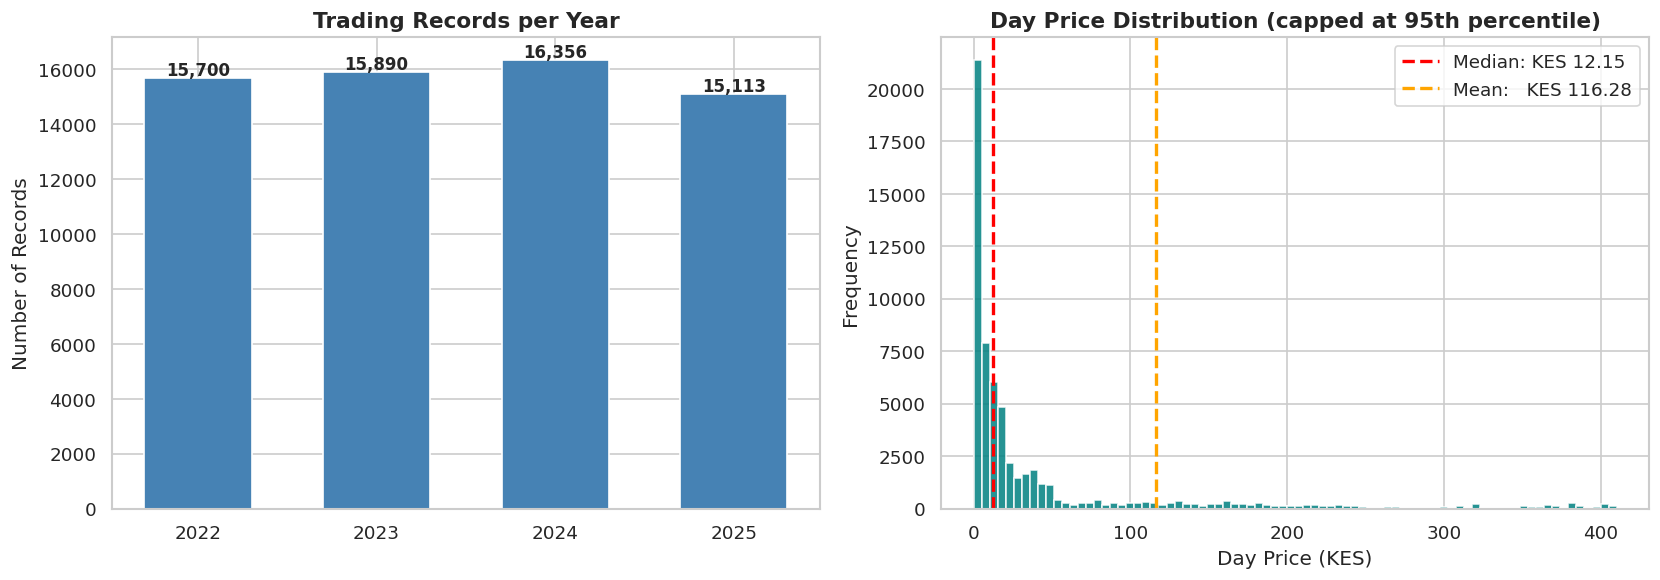

Summary Statistics
       day_price   day_low  day_high        volume  changepct
count   63059.00  63059.00  63059.00  6.305900e+04   63059.00
mean      116.28    115.91    117.00  2.621158e+05       0.44
std       431.47    430.70    436.39  2.110072e+06       4.67
min         0.01      0.01      0.02  0.000000e+00     -96.47
25%         3.70      3.65      3.80  0.000000e+00       0.00
50%        12.15     12.00     12.40  2.300000e+03       0.00
75%        41.65     41.00     42.30  3.300000e+04       0.90
max      5335.00   5100.00   9800.00  2.084859e+08     910.43


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Records per year
yr_counts = nse_data.groupby('year').size()
axes[0].bar(yr_counts.index.astype(str), yr_counts.values,
            color='steelblue', edgecolor='white', width=0.6)
axes[0].set_title('Trading Records per Year', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Records')
for i, v in enumerate(yr_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

# Price distribution (capped at 95th percentile to handle outliers)
prices = nse_data['day_price']
cap    = prices.quantile(0.95)
axes[1].hist(prices[prices <= cap], bins=80, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(prices.median(), color='red',    lw=2, linestyle='--',
                label=f'Median: KES {prices.median():.2f}')
axes[1].axvline(prices.mean(),   color='orange', lw=2, linestyle='--',
                label=f'Mean:   KES {prices.mean():.2f}')
axes[1].set_title('Day Price Distribution (capped at 95th percentile)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day Price (KES)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Summary Statistics')
print(nse_data[['day_price','day_low','day_high','volume','changepct']].describe().round(2))

Top 15 Stocks by Average Daily Volume

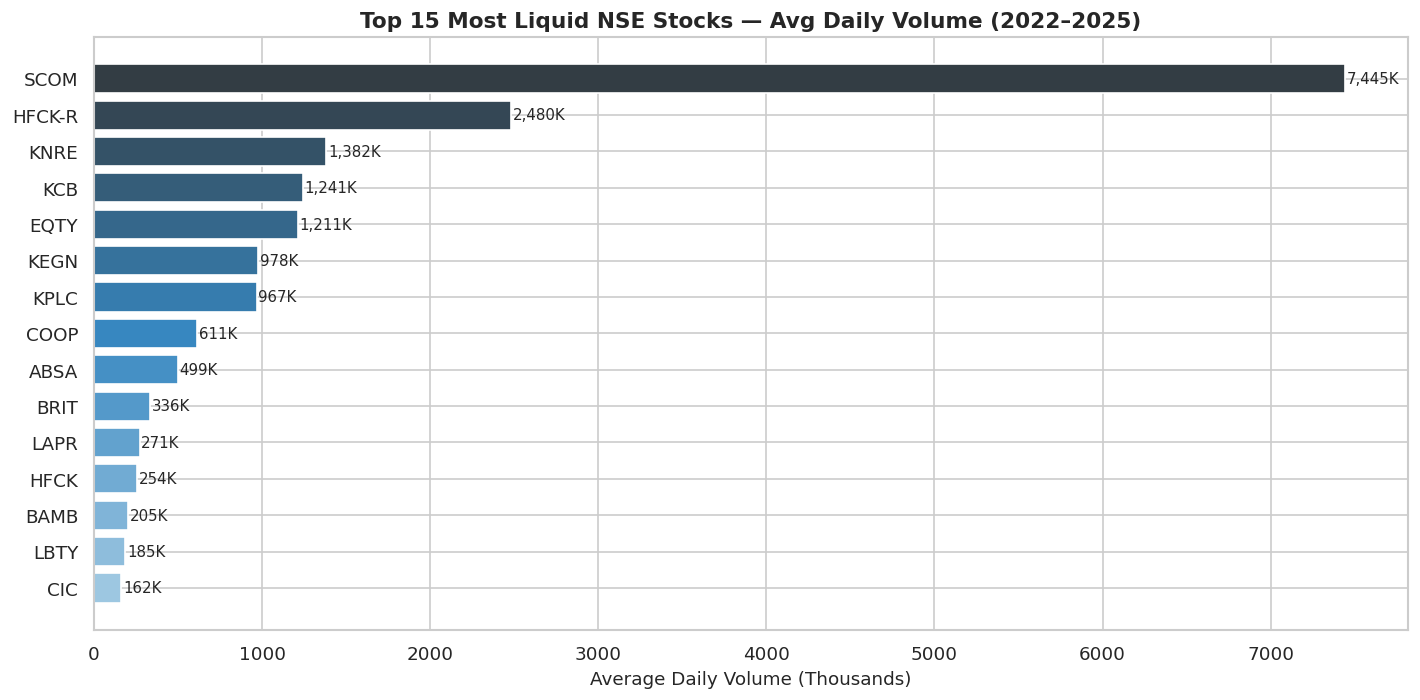


Top 15 Stocks by Avg Daily Volume:
       Avg Daily Volume
code                   
SCOM          7,445,002
HFCK-R        2,479,807
KNRE          1,381,571
KCB           1,241,449
EQTY          1,211,458
KEGN            978,047
KPLC            966,687
COOP            611,365
ABSA            499,242
BRIT            335,582
LAPR            271,351
HFCK            253,649
BAMB            204,653
LBTY            184,833
CIC             161,821


In [23]:
top15_vol = (nse_data.groupby('code')['volume']
             .mean()
             .sort_values(ascending=False)
             .head(15))

fig, ax = plt.subplots(figsize=(12, 6))
colors  = sns.color_palette('Blues_d', 15)
bars    = ax.barh(top15_vol.index[::-1], top15_vol.values[::-1] / 1e3,
                  color=colors, edgecolor='white')
ax.set_xlabel('Average Daily Volume (Thousands)', fontsize=11)
ax.set_title('Top 15 Most Liquid NSE Stocks — Avg Daily Volume (2022–2025)',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, top15_vol.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'{val/1e3:,.0f}K', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 15 Stocks by Avg Daily Volume:')
print(top15_vol.rename('Avg Daily Volume').apply(lambda x: f'{x:,.0f}').to_frame())

Price Trends for Blue Chip Stocks

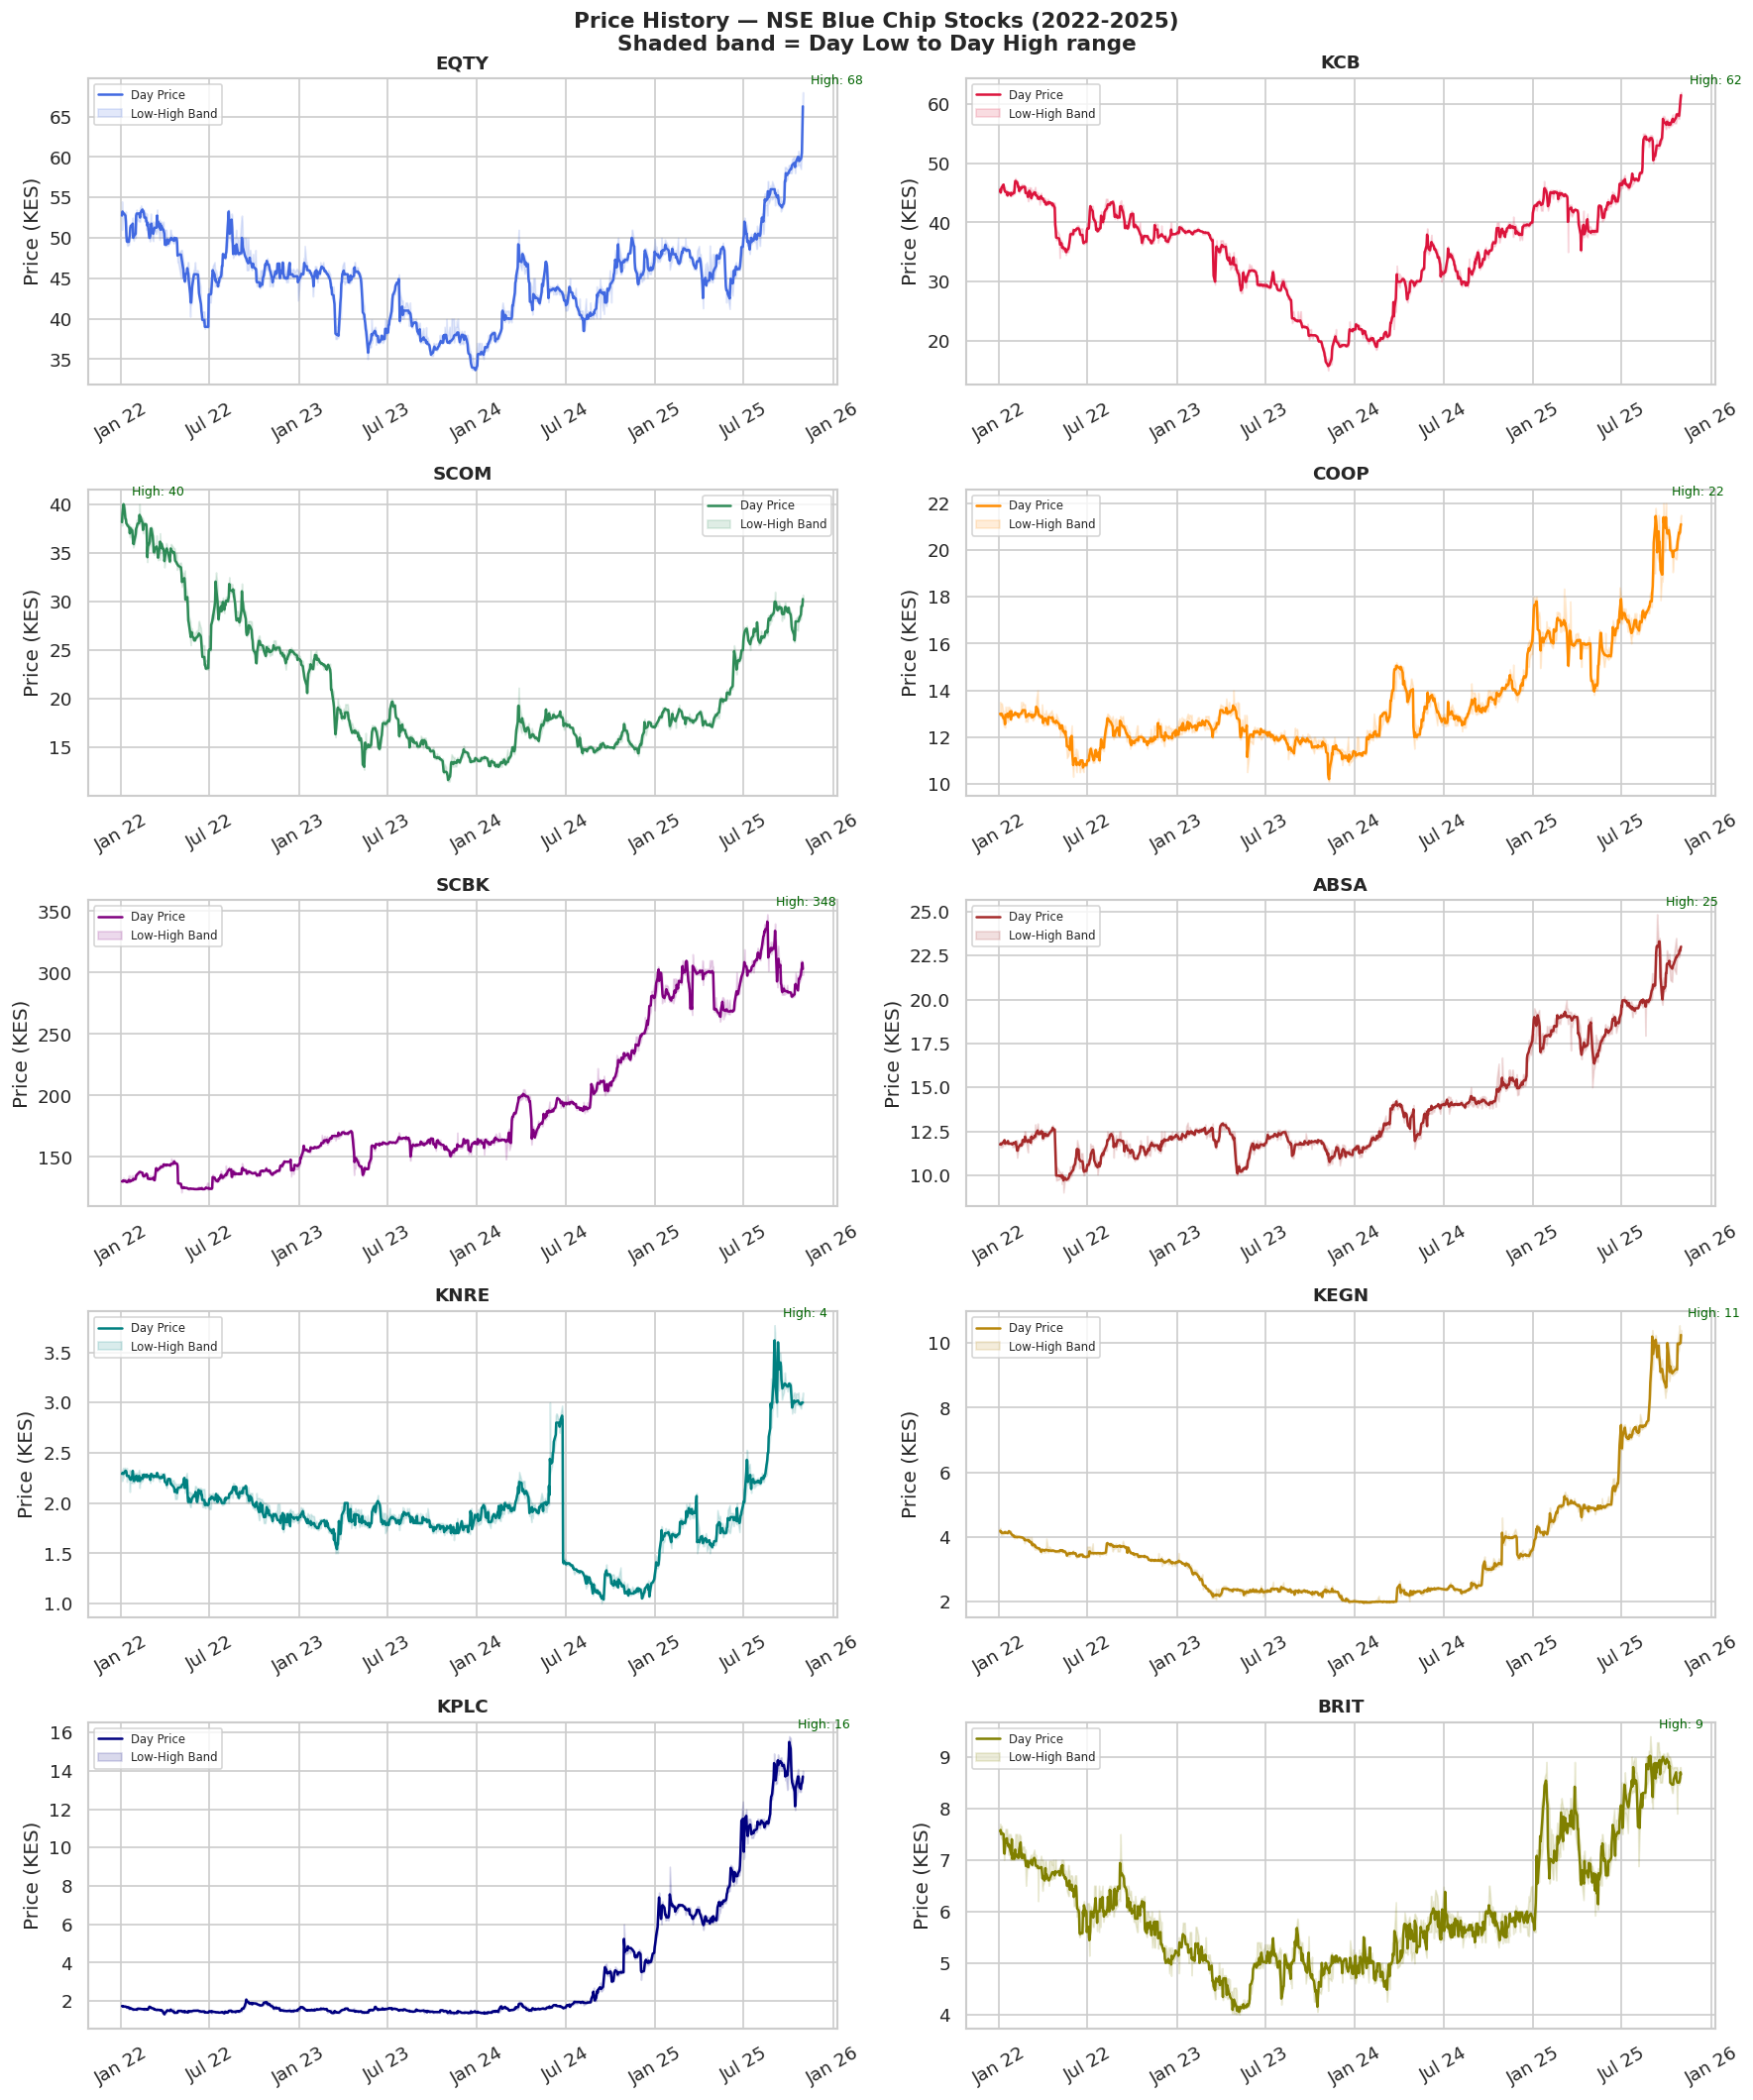

In [24]:
colors_bc = ['royalblue','crimson','seagreen','darkorange',
              'purple','brown','teal','darkgoldenrod','navy','olive']

fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes      = axes.flatten()

for i, (code, color) in enumerate(zip(blue_chips, colors_bc)):
    sub = nse_data[nse_data['code'] == code]
    if sub.empty:
        axes[i].set_visible(False)
        continue
    axes[i].plot(sub['date'], sub['day_price'], color=color, lw=1.5, label='Day Price')
    axes[i].fill_between(sub['date'], sub['day_low'], sub['day_high'],
                         alpha=0.15, color=color, label='Low-High Band')
    idx_max = sub['day_high'].idxmax()
    axes[i].annotate(
        f"High: {sub.loc[idx_max,'day_high']:.0f}",
        xy=(sub.loc[idx_max, 'date'], sub.loc[idx_max, 'day_high']),
        fontsize=7.5, color='darkgreen',
        xytext=(5, 5), textcoords='offset points'
    )
    axes[i].set_title(f'{code}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Price (KES)')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=7)

fig.suptitle(
    'Price History — NSE Blue Chip Stocks (2022-2025)\n'
    'Shaded band = Day Low to Day High range',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


Top 15 Most Volatile Stocks

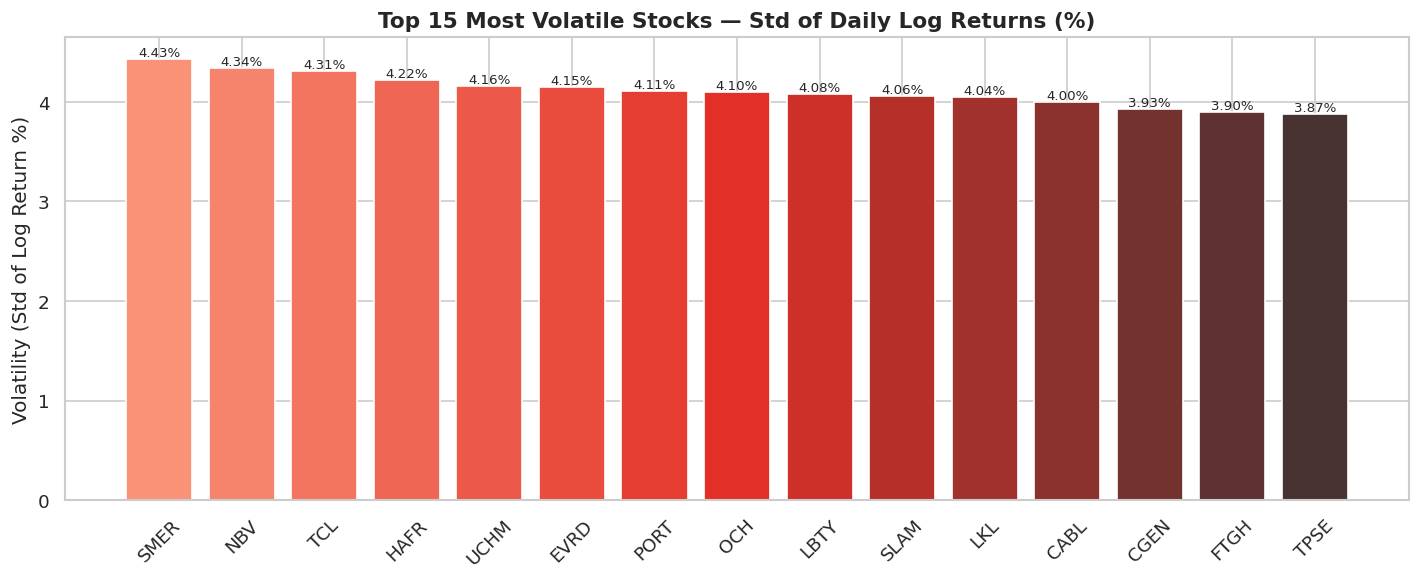

Top 15 Most Volatile Stocks (Daily Log Return Std):
      Volatility %
code              
SMER         4.429
NBV          4.341
TCL          4.310
HAFR         4.217
UCHM         4.159
EVRD         4.152
PORT         4.107
OCH          4.095
LBTY         4.079
SLAM         4.062
LKL          4.045
CABL         4.001
CGEN         3.927
FTGH         3.901
TPSE         3.874


In [25]:
# Exclude HFCK-R, extreme outlier due to rights-issue pricing distortion
vol_std = (nse_data[nse_data['code'] != 'HFCK-R']
           .groupby('code')['log_return']
           .std()
           .dropna()
           .sort_values(ascending=False)
           .head(15))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(vol_std.index, vol_std.values * 100,
              color=sns.color_palette('Reds_d', 15), edgecolor='white')
ax.set_title('Top 15 Most Volatile Stocks — Std of Daily Log Returns (%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Volatility (Std of Log Return %)')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, vol_std.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val*100:.2f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 15 Most Volatile Stocks (Daily Log Return Std):')
print((vol_std * 100).round(3).rename('Volatility %').to_frame())

Year-Over-Year Price Trends for Blue Chip Stocks

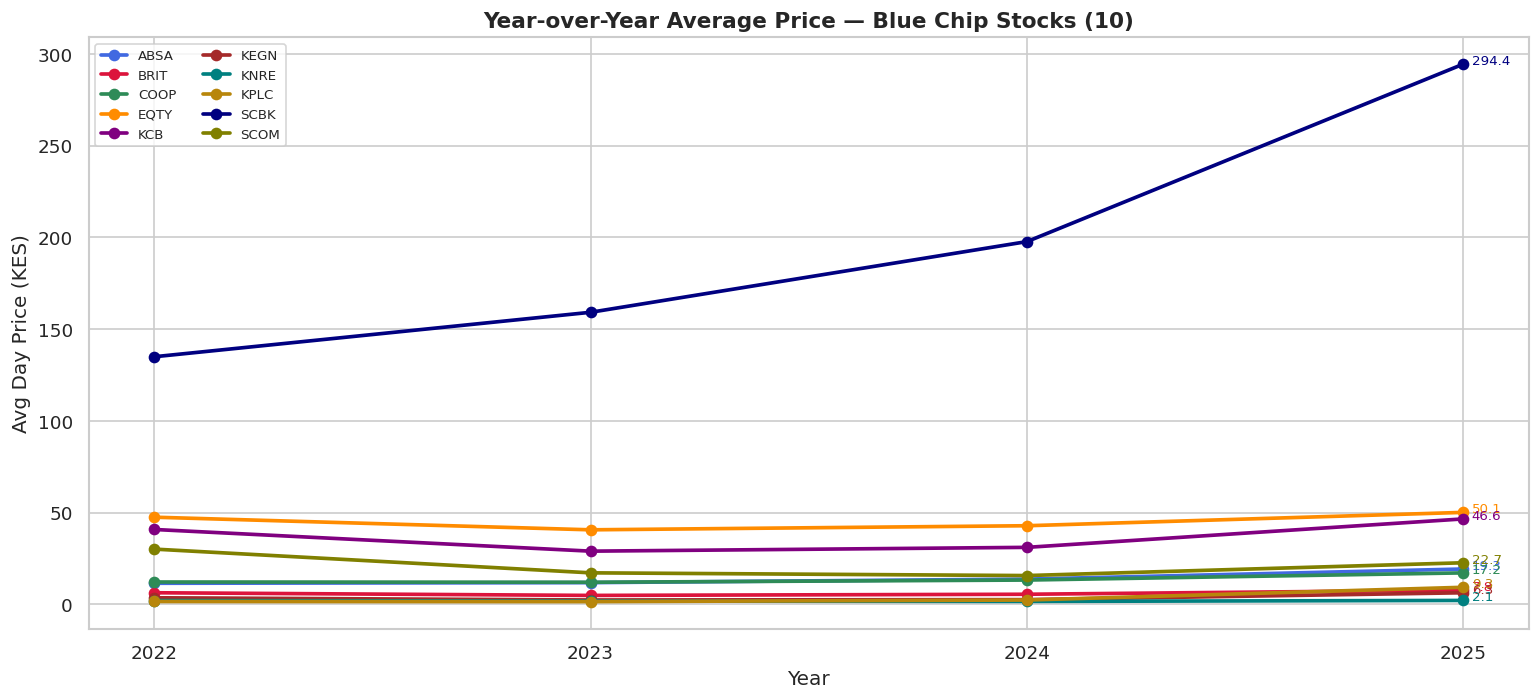


Yearly Average Prices (KES):
year    2022    2023    2024    2025
code                                
ABSA   11.49   11.84   13.77   19.27
BRIT    6.33    4.88    5.52    7.76
COOP   12.19   12.06   13.26   17.16
EQTY   47.50   40.63   42.85   50.13
KCB    40.82   29.00   31.07   46.57
KEGN    3.59    2.40    2.58    6.32
KNRE    2.08    1.81    1.62    2.15
KPLC    1.57    1.50    2.36    9.31
SCBK  134.93  159.16  197.68  294.41
SCOM   30.12   17.18   15.70   22.68


In [26]:
yearly_avg = (nse_data[nse_data['code'].isin(blue_chips)]
              .groupby(['code', 'year'])['day_price']
              .mean()
              .unstack())

fig, ax = plt.subplots(figsize=(13, 6))
for code, color in zip(yearly_avg.index, colors_bc):
    ax.plot(yearly_avg.columns.astype(str), yearly_avg.loc[code],
            marker='o', lw=2.2, label=code, color=color)
    ax.annotate(
        f'{yearly_avg.loc[code].iloc[-1]:.1f}',
        xy=(str(yearly_avg.columns[-1]), yearly_avg.loc[code].iloc[-1]),
        xytext=(5, 0), textcoords='offset points', fontsize=8, color=color
    )
ax.set_title('Year-over-Year Average Price — Blue Chip Stocks (10)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Day Price (KES)')
ax.set_xlabel('Year')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print('\nYearly Average Prices (KES):')
print(yearly_avg.round(2))


Correlation Matrix

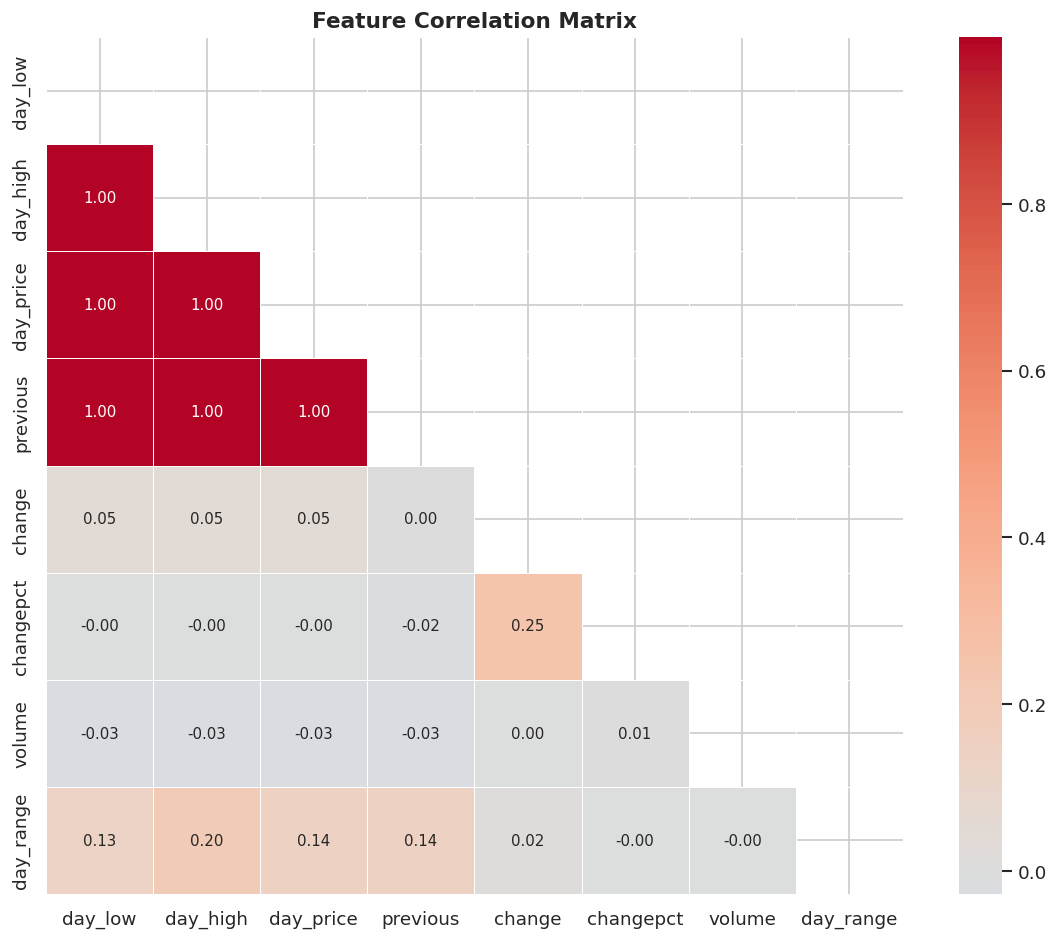


Key correlations with day_price:
day_low      1.000
previous     0.999
day_high     0.998
day_range    0.142
change       0.048
changepct   -0.005
volume      -0.027
Name: day_price, dtype: float64


In [27]:
corr_cols = ['day_low','day_high','day_price','previous',
             'change','changepct','volume','day_range']
corr = nse_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey correlations with day_price:')
print(corr['day_price'].drop('day_price').sort_values(ascending=False).round(3))

Volume ANalysis: Zero-Day Volume & Distribution

/tmp/ipykernel_7435/1985302939.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zero_by_year = nse_data.groupby('year').apply(


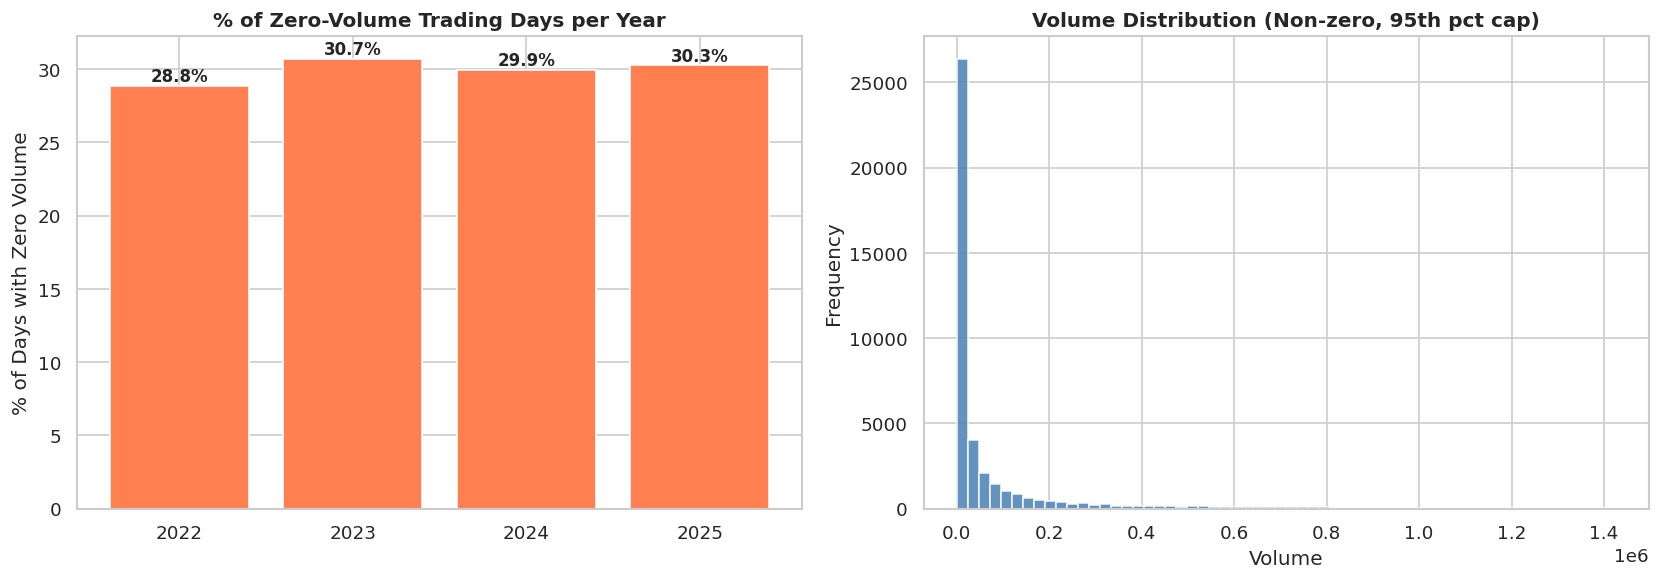

Total zero-volume records : 18,878 (29.9%)
Total non-zero records    : 44,181

Volume stats (non-zero):
count        44181.0
mean        374115.0
std        2512570.0
min              1.0
25%           1700.0
50%          11700.0
75%          81600.0
max      208485900.0
Name: volume, dtype: float64


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Zero volume days per year
zero_by_year = nse_data.groupby('year').apply(
    lambda x: (x['volume'] == 0).mean() * 100
)
axes[0].bar(zero_by_year.index.astype(str), zero_by_year.values,
            color='coral', edgecolor='white')
axes[0].set_title('% of Zero-Volume Trading Days per Year',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('% of Days with Zero Volume')
for i, v in enumerate(zero_by_year.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Volume distribution (non-zero only, capped at 95th pct)
vol_nz  = nse_data[nse_data['volume'] > 0]['volume']
cap_v   = vol_nz.quantile(0.95)
axes[1].hist(vol_nz[vol_nz <= cap_v], bins=60, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[1].set_title('Volume Distribution (Non-zero, 95th pct cap)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Volume')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

total_zero = (nse_data['volume'] == 0).sum()
print(f'Total zero-volume records : {total_zero:,} ({total_zero/len(nse_data)*100:.1f}%)')
print(f'Total non-zero records    : {(nse_data["volume"]>0).sum():,}')
print(f'\nVolume stats (non-zero):')
print(vol_nz.describe().round(0))

IntraDay Range: Which Stocks Move Most Within a Day (Day High - Day Low)?

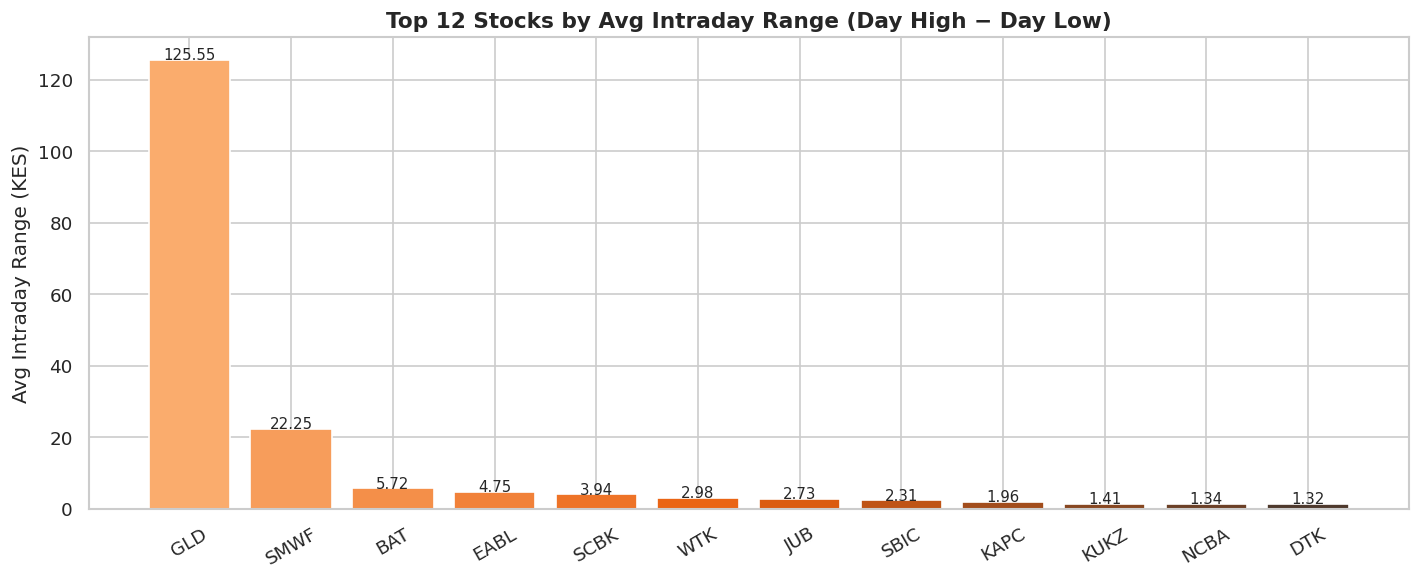


Top 10 by Relative Intraday Range (% of price):
        Range %
code           
HFCK-R   55.688
UCHM      7.131
HAFR      7.001
EVRD      6.621
SMER      5.873
CABL      5.741
HFCK      5.655
BRIT      5.478
CIC       5.236
KPLC      5.080


In [29]:
top_range = (nse_data.groupby('code')['day_range']
             .mean()
             .sort_values(ascending=False)
             .head(12))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_range.index, top_range.values,
       color=sns.color_palette('Oranges_d', 12), edgecolor='white')
ax.set_title('Top 12 Stocks by Avg Intraday Range (Day High − Day Low)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Intraday Range (KES)')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(top_range.values):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Also show as % of price (relative range)
avg_price = nse_data.groupby('code')['day_price'].mean()
rel_range = (nse_data.groupby('code')['day_range'].mean() / avg_price * 100).dropna()
print('\nTop 10 by Relative Intraday Range (% of price):')
print(rel_range.sort_values(ascending=False).head(10).round(3).rename('Range %').to_frame())

Return Distributions for Blue Chip Stocks

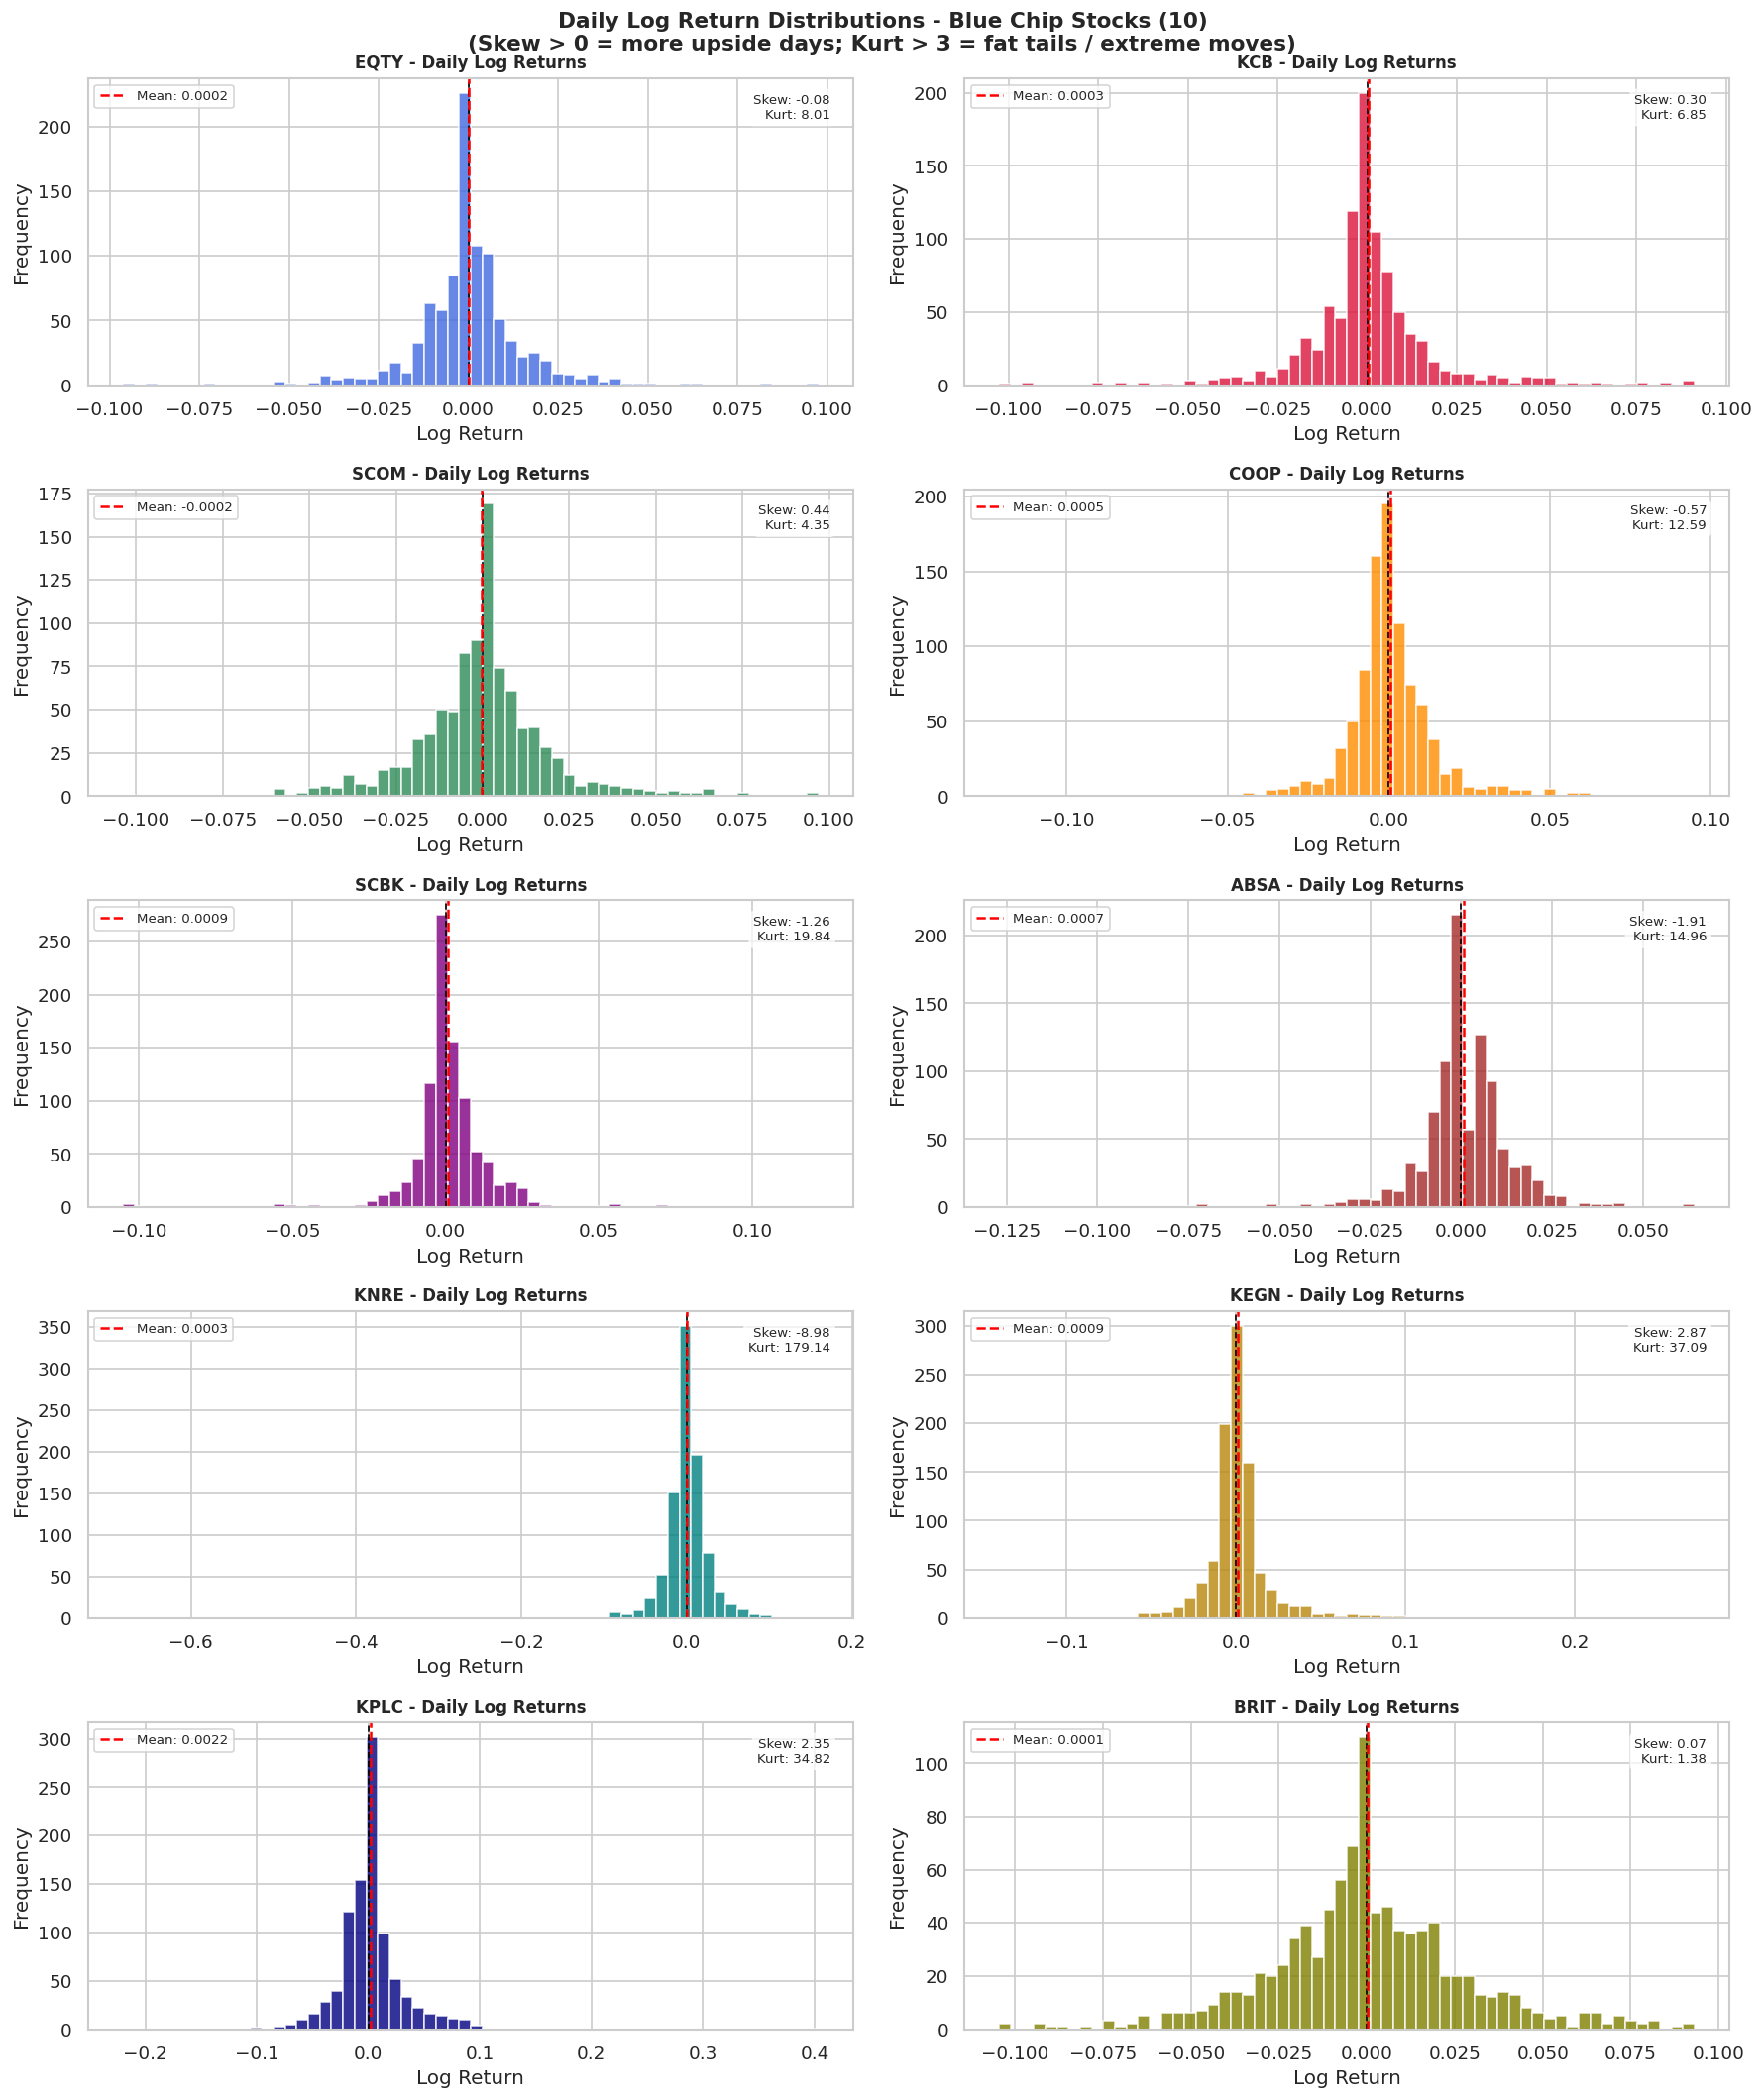

Return Statistics Summary:
       Mean Return  Std (Vol)  Skewness  Kurtosis  Max Gain%  Max Loss%
Stock                                                                  
EQTY       0.00024    0.01479    -0.083     8.009       9.76      -9.63
KCB        0.00032    0.01865     0.301     6.854       9.13     -10.26
SCOM      -0.00025    0.01995     0.436     4.354       9.69     -10.38
COOP       0.00051    0.01537    -0.567    12.591       9.50     -12.09
SCBK       0.00090    0.01483    -1.262    19.840      12.17     -10.54
ABSA       0.00071    0.01449    -1.914    14.956       6.43     -12.71
KNRE       0.00029    0.03385    -8.979   179.138      15.96     -68.26
KEGN       0.00095    0.02050     2.867    37.089      27.09     -14.00
KPLC       0.00219    0.03058     2.352    34.823      40.36     -22.03
BRIT       0.00014    0.02731     0.072     1.381       9.32     -10.45


In [30]:
fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes      = axes.flatten()

for i, (code, color) in enumerate(zip(blue_chips, colors_bc)):
    sub = nse_data[nse_data['code'] == code]['log_return'].dropna()
    if sub.empty:
        axes[i].set_visible(False)
        continue
    axes[i].hist(sub, bins=60, color=color, edgecolor='white', alpha=0.8)
    axes[i].axvline(0,          color='black', lw=1,   linestyle='--')
    axes[i].axvline(sub.mean(), color='red',   lw=1.5, linestyle='--',
                    label=f'Mean: {sub.mean():.4f}')
    axes[i].set_title(f'{code} - Daily Log Returns', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Log Return')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)
    axes[i].text(
        0.97, 0.95,
        f'Skew: {sub.skew():.2f}\nKurt: {sub.kurt():.2f}',
        transform=axes[i].transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

fig.suptitle('Daily Log Return Distributions - Blue Chip Stocks (10)\n'
             '(Skew > 0 = more upside days; Kurt > 3 = fat tails / extreme moves)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Return Statistics Summary:')
stats = []
for code in blue_chips:
    sub = nse_data[nse_data['code'] == code]['log_return'].dropna()
    if sub.empty:
        continue
    stats.append({
        'Stock':        code,
        'Mean Return':  round(sub.mean(), 5),
        'Std (Vol)':    round(sub.std(),  5),
        'Skewness':     round(sub.skew(), 3),
        'Kurtosis':     round(sub.kurt(), 3),
        'Max Gain%':    round(sub.max() * 100, 2),
        'Max Loss%':    round(sub.min() * 100, 2),
    })
print(pd.DataFrame(stats).set_index('Stock').to_string())


## Feature Engineering
Before we can train any model, we need to create features that represent what we actually know at the time of prediction (past data). We shift everything by 1 day so that today's model input never includes today's outcome.
We're creating three types of features:

- Lag features - yesterday's price, the day before, etc. to captures recent momentum.
* Rolling stats - 5-day and 20-day averages and standard deviation, to captures short and medium-term trend and volatility.
* Context features - where is the stock in its 52-week range, volume relative to normal, day of week.

At the end we create our targets: next-day Low, High, and Price.

In [31]:
# Sort by stock and date first
nse_data = nse_data.sort_values(['code', 'date']).reset_index(drop=True)

#  Lag features
# "What was the price yesterday, two days ago, three days ago?"
# .shift(1) per stock means we never use today's value to predict today

nse_data['price_lag1'] = nse_data.groupby('code')['day_price'].shift(1)
nse_data['price_lag2'] = nse_data.groupby('code')['day_price'].shift(2)
nse_data['price_lag3'] = nse_data.groupby('code')['day_price'].shift(3)

nse_data['low_lag1']   = nse_data.groupby('code')['day_low'].shift(1)
nse_data['low_lag2']   = nse_data.groupby('code')['day_low'].shift(2)

nse_data['high_lag1']  = nse_data.groupby('code')['day_high'].shift(1)
nse_data['high_lag2']  = nse_data.groupby('code')['day_high'].shift(2)

nse_data['volume_lag1'] = nse_data.groupby('code')['volume'].shift(1)

In [32]:
# Rolling means and std
# What has the average price been over the last 5 / 20 trading days?
# .shift(1) before .rolling() ensures we don't include today

nse_data['price_roll5_mean']  = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).rolling(5).mean()
)
nse_data['price_roll20_mean'] = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).rolling(20).mean()
)
nse_data['price_roll5_std']   = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).rolling(5).std()
)

In [33]:
# Exponentially Weighted Mean
# Like a rolling mean but more weight on recent days — reacts faster to changes
nse_data['price_ewm5']  = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).ewm(span=5).mean()
)
nse_data['price_ewm20'] = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).ewm(span=20).mean()
)

In [34]:
# 52-week relative position
# "Where is today's price relative to its annual range?"
# 0 = at 12-month low, 1 = at 12-month high
# Helps the model understand whether the stock is stretched or depressed
nse_data['price_pos_52w'] = (
    (nse_data['day_price'] - nse_data['12m_low']) /
    (nse_data['12m_high'] - nse_data['12m_low'] + 1e-6)
)

In [35]:
#  Volume ratio
# "Is today's volume unusually high or low vs the recent norm?"
# High ratio = unusual activity, which often precedes price moves
nse_data['volume_ratio'] = nse_data['volume'] / (nse_data['price_roll20_mean'] + 1e-6)


In [36]:
# Day of week
# Monday=0, Friday=4. Markets behave slightly differently by weekday
nse_data['dow_num'] = nse_data['date'].dt.dayofweek




In [37]:
# Intraday range lag
# How wide was yesterday's high-low band? Proxy for recent volatility
nse_data['range_lag1'] = nse_data['high_lag1'] - nse_data['low_lag1']

In [38]:
# Create targets
# What we want to predict: the NEXT day's low, high, and close price
# .shift(-1) moves tomorrow's value into today's row
nse_data['next_day_low']   = nse_data.groupby('code')['day_low'].shift(-1)
nse_data['next_day_high']  = nse_data.groupby('code')['day_high'].shift(-1)
nse_data['next_day_price'] = nse_data.groupby('code')['day_price'].shift(-1)


In [39]:
# Drop rows with missing targets or missing lag1
# The last row per stock has no next-day target (nothing to predict)
# First few rows per stock have no lag history yet
nse_data = nse_data.dropna(subset=[
    'next_day_low', 'next_day_high', 'next_day_price', 'price_lag1'
]).reset_index(drop=True)


In [40]:
print(f'Shape after feature engineering: {nse_data.shape}')
print(f'Date range: {nse_data["date"].min().date()} to {nse_data["date"].max().date()}')

Shape after feature engineering: (62901, 37)
Date range: 2022-01-04 to 2025-10-30


### Walk-Forward Split
Stock data is sequential. Splitting randomly would let the model train on future data to predict the past.

* Train: 2022 - 2023 - what the model learns from
* Validation: 2024 - used to tune and compare models
* Test: 2025 - used for testing

In [41]:
TRAIN_END = '2023-12-31'
VAL_END   = '2024-12-31'

train = nse_data[nse_data['date'] <= TRAIN_END].copy()
val   = nse_data[(nse_data['date'] > TRAIN_END) & (nse_data['date'] <= VAL_END)].copy()
test  = nse_data[nse_data['date'] > VAL_END].copy()

print(f'Train : {train["date"].min().date()} - {train["date"].max().date()}  ({len(train):,} rows)')
print(f'Val   : {val["date"].min().date()} - {val["date"].max().date()}  ({len(val):,} rows)')
print(f'Test  : {test["date"].min().date()} - {test["date"].max().date()}  ({len(test):,} rows)')

Train : 2022-01-04 - 2023-12-29  (31,521 rows)
Val   : 2024-01-02 - 2024-12-31  (16,351 rows)
Test  : 2025-01-02 - 2025-10-30  (15,029 rows)


### Evaluation Metric Setup
We use three metrics to evaluate the model:

- MAE (Mean Absolute Error) - average KES error. Interpretation: "on average, we're off by X shillings."
- RMSE - penalises large errors more. If RMSE >> MAE, the model occasionally makes very bad forecasts.
- MAPE - percentage error. Compare across stocks with different price levels (SCOM at 15 KES vs BAT at 600 KES).

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

TARGETS = ['day_low', 'day_high', 'day_price']
TARGET_LABELS = {'day_low': 'Day Low', 'day_high': 'Day High', 'day_price': 'Day Price'}

results = {}  # cllect all model results here

def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-6))) * 100
    if label:
        print(f'  {label:<30} MAE={mae:>8.4f}  RMSE={rmse:>8.4f}  MAPE={mape:>6.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

### Baseline 1 - Persistence
Predict tomorrow = today by repeating the last known value.
Check if model's MAE is higher than persistence.

In [43]:
results['Persistence'] = {}

# For day_price: predict next_day_price = price_lag1 (yesterday's price, from val's perspective)
# For day_low:   predict next_day_low  = low_lag1
# For day_high:  predict next_day_high = high_lag1

persistence_map = {
    'day_price': 'price_lag1',
    'day_low':   'low_lag1',
    'day_high':  'high_lag1',
}

for target in TARGETS:
    lag_col = persistence_map[target]
    mask = val[lag_col].notna()
    y_true = val.loc[mask, f'next_{target}']
    y_pred = val.loc[mask, lag_col]
    metrics = evaluate(y_true, y_pred, label=TARGET_LABELS[target])
    results['Persistence'][target] = metrics

  Day Low                        MAE=  0.9297  RMSE=  6.9987  MAPE=  3.11%
  Day High                       MAE=  0.9173  RMSE=  6.9873  MAPE=  2.67%
  Day Price                      MAE=  0.8660  RMSE=  6.9211  MAPE=  2.85%


### Baseline 2 - Rolling Mean & EWM
-  Predict tomorrow's price using the average of the last 5 days. The EWM version gives more weight to recent days so it reacts faster to recent moves.
- It smooths out noise.
- If EWM beats rolling mean, recent days matter more than older history - that's a signal to use shorter windows in your models. If both lose to persistence, the market is mean-reverting on short timescales.

In [44]:
results['Rolling5'] = {}
results['EWM5']     = {}

for target in TARGETS:
    y_true = val[f'next_{target}']
    mask   = val['price_roll5_mean'].notna() & val['price_ewm5'].notna()

    # We use the price rolling/ewm as a proxy for all three targets
    # (a more precise version would compute roll5 for low and high separately
    y_roll = val['price_roll5_mean']
    y_ewm  = val['price_ewm5']

    print(f'  -- {TARGET_LABELS[target]} --')
    r_metrics = evaluate(y_true[mask], y_roll[mask], label='Rolling 5-day Mean')
    e_metrics = evaluate(y_true[mask], y_ewm[mask],  label='EWM span=5')
    results['Rolling5'][target] = r_metrics
    results['EWM5'][target]     = e_metrics
    print()

  -- Day Low --
  Rolling 5-day Mean             MAE=  1.1648  RMSE=  7.3965  MAPE=  4.37%
  EWM span=5                     MAE=  1.1032  RMSE=  7.2599  MAPE=  4.07%

  -- Day High --
  Rolling 5-day Mean             MAE=  1.2295  RMSE=  7.4088  MAPE=  3.41%
  EWM span=5                     MAE=  1.1706  RMSE=  7.2766  MAPE=  3.26%

  -- Day Price --
  Rolling 5-day Mean             MAE=  1.1395  RMSE=  7.3510  MAPE=  4.09%
  EWM span=5                     MAE=  1.0739  RMSE=  7.2143  MAPE=  3.73%



### Baseline model Visualization

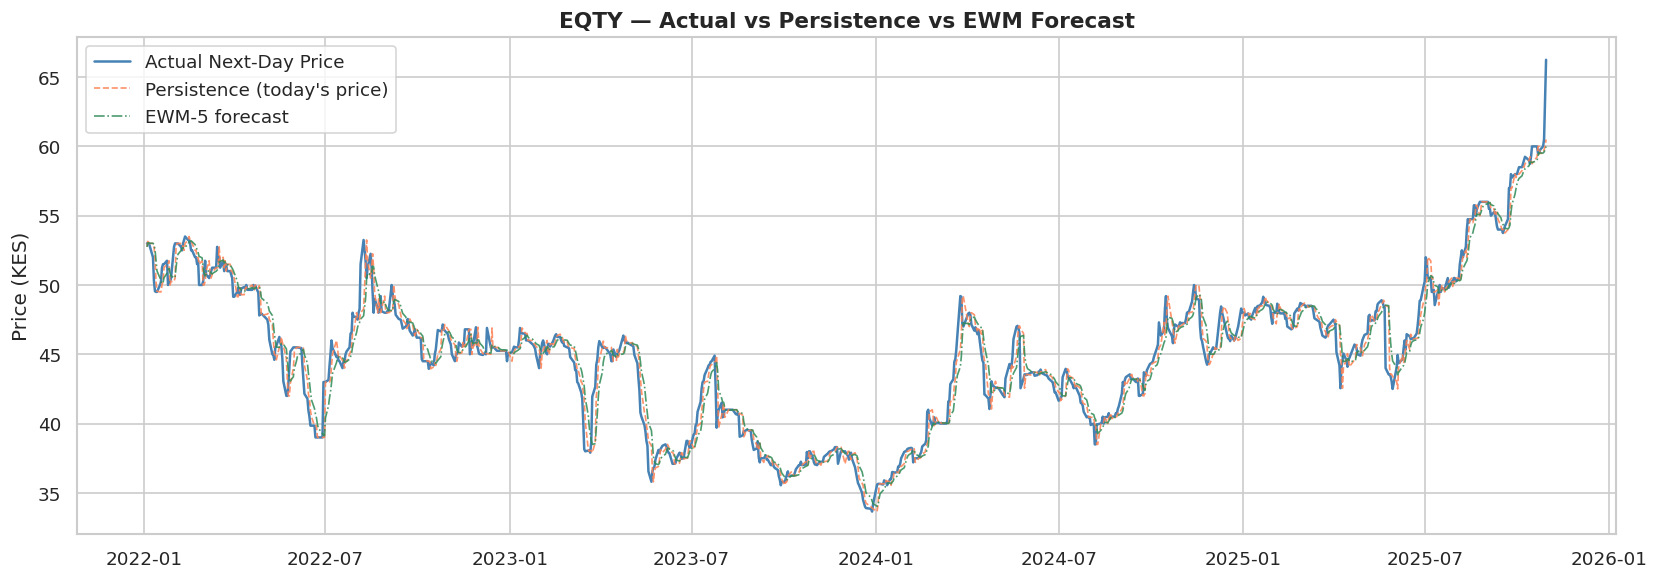

In [45]:
import matplotlib.pyplot as plt

stock = 'EQTY'
sub   = nse_data[nse_data['code'] == stock].copy()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(sub['date'], sub['next_day_price'],  label='Actual Next-Day Price',
        color='steelblue', lw=1.5)
ax.plot(sub['date'], sub['price_lag1'],      label='Persistence (today\'s price)',
        color='coral', lw=1, linestyle='--', alpha=0.85)
ax.plot(sub['date'], sub['price_ewm5'],      label='EWM-5 forecast',
        color='seagreen', lw=1, linestyle='-.', alpha=0.85)

ax.set_title(f'{stock} — Actual vs Persistence vs EWM Forecast', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (KES)')
ax.legend()
plt.tight_layout()
plt.show()

### Model 1 - Ridge Regression with Lag Features
- Ridge adds a penalty (alpha) to prevent any single feature from dominating therefore helpful here because price_lag1 and price_roll5_mean are highly correlated.

In [46]:
from sklearn.linear_model import Ridge

FEATURE_COLS = [
    'price_lag1', 'price_lag2', 'price_lag3',
    'low_lag1',   'low_lag2',
    'high_lag1',  'high_lag2',
    'volume_lag1',
    'price_roll5_mean', 'price_roll20_mean',
    'price_roll5_std',
    'price_ewm5', 'price_ewm20',
    'price_pos_52w',
    'volume_ratio',
    'dow_num',
    'range_lag1',
]

# Only keep features that exist
FEATURE_COLS = [c for c in FEATURE_COLS if c in nse_data.columns]

results['RidgeRegression'] = {}
lr_models = {}

for target in TARGETS:
    # rows with no NaN in features or target
    train_clean = train[FEATURE_COLS + [f'next_{target}']].dropna()
    val_clean   = val[FEATURE_COLS + [f'next_{target}']].dropna()

    X_train = train_clean[FEATURE_COLS]
    y_train = train_clean[f'next_{target}']
    X_val   = val_clean[FEATURE_COLS]
    y_val   = val_clean[f'next_{target}']

    model = Ridge(alpha=100.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    metrics = evaluate(y_val, y_pred, label=TARGET_LABELS[target])
    results['RidgeRegression'][target] = metrics
    lr_models[target] = model

# Print coefficients for day_price model
coef_df = pd.DataFrame({
    'Feature':     FEATURE_COLS,
    'Coefficient': lr_models['day_price'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('\nTop 10 features by absolute coefficient (Day Price model):')
print(coef_df.head(10).to_string(index=False))

  Day Low                        MAE=  0.9786  RMSE=  7.0243  MAPE=  4.24%
  Day High                       MAE=  0.9706  RMSE=  6.9627  MAPE=  5.02%
  Day Price                      MAE=  0.9273  RMSE=  6.9567  MAPE=  2.76%

Top 10 features by absolute coefficient (Day Price model):
          Feature  Coefficient
       price_lag1     0.369676
      price_ewm20     0.360439
         low_lag1     0.348260
        high_lag1     0.310626
price_roll20_mean    -0.255043
       price_lag2    -0.196830
  price_roll5_std     0.154431
         low_lag2     0.092175
        high_lag2     0.092122
       price_ewm5    -0.083518


Ridge Regression (MAE 0.927) does not improve on Persistence (MAE 0.866) for Day Price.

In [47]:
# =========================
# FIX FEATURE ENGINEERING
# =========================

# Proper rolling average of volume by stock
nse_data['volume_roll20_mean'] = (
    nse_data.groupby('code')['volume']
    .transform(lambda x: x.shift(1).rolling(20).mean())
)

# Correct volume ratio:
# current volume relative to recent average volume for the same stock
nse_data['volume_ratio'] = nse_data['volume'] / (nse_data['volume_roll20_mean'] + 1e-6)

# Optional but useful: previous day's trading range
if 'range_lag1' not in nse_data.columns:
    nse_data['range_lag1'] = (
        nse_data.groupby('code')
        .apply(lambda g: (g['day_high'] - g['day_low']).shift(1))
        .reset_index(level=0, drop=True)
    )

# Rebuild chronological splits so the updated features are definitely included
TRAIN_END = '2023-12-31'
VAL_END   = '2024-12-31'

train = nse_data[nse_data['date'] <= TRAIN_END].copy()
val   = nse_data[(nse_data['date'] > TRAIN_END) & (nse_data['date'] <= VAL_END)].copy()
test  = nse_data[nse_data['date'] > VAL_END].copy()

print("Feature fix applied.")
print(f"Train : {train['date'].min().date()} - {train['date'].max().date()} ({len(train):,} rows)")
print(f"Val   : {val['date'].min().date()} - {val['date'].max().date()} ({len(val):,} rows)")
print(f"Test  : {test['date'].min().date()} - {test['date'].max().date()} ({len(test):,} rows)")

Feature fix applied.
Train : 2022-01-04 - 2023-12-29 (31,521 rows)
Val   : 2024-01-02 - 2024-12-31 (16,351 rows)
Test  : 2025-01-02 - 2025-10-30 (15,029 rows)


In [48]:
# =========================
# LIGHTGBM: TRAIN, TUNE, EVALUATE
# =========================

from lightgbm import LGBMRegressor
from sklearn.model_selection import ParameterGrid

# Ensure the corrected feature is included
FEATURE_COLS = [
    'price_lag1', 'price_lag2', 'price_lag3',
    'low_lag1',   'low_lag2',
    'high_lag1',  'high_lag2',
    'volume_lag1',
    'price_roll5_mean', 'price_roll20_mean',
    'price_roll5_std',
    'price_ewm5', 'price_ewm20',
    'price_pos_52w',
    'volume_roll20_mean',
    'volume_ratio',
    'dow_num',
    'range_lag1',
]

FEATURE_COLS = [c for c in FEATURE_COLS if c in nse_data.columns]

results['LightGBM'] = {}
lgbm_models = {}
lgbm_best_params = {}
lgbm_predictions = {}

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'max_depth': [-1, 5, 10],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

for target in TARGETS:
    train_clean = train[FEATURE_COLS + [f'next_{target}', 'date', 'code']].dropna()
    val_clean   = val[FEATURE_COLS + [f'next_{target}', 'date', 'code']].dropna()
    test_clean  = test[FEATURE_COLS + [f'next_{target}', 'date', 'code']].dropna()

    X_train = train_clean[FEATURE_COLS]
    y_train = train_clean[f'next_{target}']

    X_val = val_clean[FEATURE_COLS]
    y_val = val_clean[f'next_{target}']

    X_test = test_clean[FEATURE_COLS]
    y_test = test_clean[f'next_{target}']

    best_model = None
    best_params = None
    best_rmse = np.inf

    for params in ParameterGrid(param_grid):
        model = LGBMRegressor(
            objective='regression',
            random_state=42,
            **params
        )
        model.fit(X_train, y_train)

        y_val_pred = model.predict(X_val)
        val_metrics = evaluate(y_val, y_val_pred)

        if val_metrics['RMSE'] < best_rmse:
            best_rmse = val_metrics['RMSE']
            best_model = model
            best_params = params

    # Validation metrics
    y_val_pred = best_model.predict(X_val)
    val_metrics = evaluate(y_val, y_val_pred, label=f'{TARGET_LABELS[target]} (Validation)')

    # Test metrics
    y_test_pred = best_model.predict(X_test)
    test_metrics = evaluate(y_test, y_test_pred, label=f'{TARGET_LABELS[target]} (Test)')

    results['LightGBM'][target] = {
        'validation': val_metrics,
        'test': test_metrics
    }

    lgbm_models[target] = best_model
    lgbm_best_params[target] = best_params

    lgbm_predictions[target] = test_clean[['date', 'code']].copy()
    lgbm_predictions[target]['actual'] = y_test.values
    lgbm_predictions[target]['predicted'] = y_test_pred

    print(f'Best params for {target}: {best_params}')
    print('-' * 90)

# -------------------------
# Combine next-day low/high/price predictions into one frame
# -------------------------
price_range_df = (
    lgbm_predictions['day_low'][['date', 'code', 'actual', 'predicted']]
    .rename(columns={'actual': 'actual_next_low', 'predicted': 'pred_next_low'})
    .merge(
        lgbm_predictions['day_high'][['date', 'code', 'actual', 'predicted']]
        .rename(columns={'actual': 'actual_next_high', 'predicted': 'pred_next_high'}),
        on=['date', 'code'],
        how='inner'
    )
    .merge(
        lgbm_predictions['day_price'][['date', 'code', 'actual', 'predicted']]
        .rename(columns={'actual': 'actual_next_price', 'predicted': 'pred_next_price'}),
        on=['date', 'code'],
        how='inner'
    )
)

price_range_df['pred_range_width'] = price_range_df['pred_next_high'] - price_range_df['pred_next_low']
price_range_df['actual_range_width'] = price_range_df['actual_next_high'] - price_range_df['actual_next_low']
price_range_df['pred_price_position_in_range'] = (
    (price_range_df['pred_next_price'] - price_range_df['pred_next_low']) /
    (price_range_df['pred_range_width'] + 1e-6)
)

print("Combined LightGBM next-day price range frame:")
display(price_range_df.head())

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

,date,code,actual_next_low,pred_next_low,actual_next_high,pred_next_high,actual_next_price,pred_next_price,pred_range_width,actual_range_width,pred_price_position_in_range
0,2025-01-02,ABSA,17.55,17.423748,19.50,18.027432,19.00,17.703406,0.603685,1.95,0.463252
1,2025-01-03,ABSA,17.55,18.232972,19.30,18.816028,18.85,18.435530,0.583055,1.75,0.347407
2,2025-01-06,ABSA,17.85,18.256922,19.25,19.033919,18.50,18.498115,0.776996,1.40,0.310416
3,2025-01-07,ABSA,18.50,18.270497,19.00,19.032908,18.80,18.494603,0.762411,0.50,0.293943
4,2025-01-08,ABSA,17.95,18.259381,19.10,19.033919,18.80,18.498115,0.774537,1.15,0.308227


In [49]:
# =========================
# FINAL SUMMARY TABLE + BUSINESS INSIGHT MARKDOWN
# =========================

from IPython.display import Markdown, display

# Compact model comparison table
summary_rows = []

for model_name, model_results in results.items():
    for target in TARGETS:
        # Some earlier models only have validation metrics, LightGBM has validation + test
        if model_name == 'LightGBM':
            summary_rows.append({
                'Model': model_name,
                'Target': target,
                'Split': 'Validation',
                'MAE': model_results[target]['validation']['MAE'],
                'RMSE': model_results[target]['validation']['RMSE'],
                'MAPE': model_results[target]['validation']['MAPE'],
            })
            summary_rows.append({
                'Model': model_name,
                'Target': target,
                'Split': 'Test',
                'MAE': model_results[target]['test']['MAE'],
                'RMSE': model_results[target]['test']['RMSE'],
                'MAPE': model_results[target]['test']['MAPE'],
            })
        else:
            summary_rows.append({
                'Model': model_name,
                'Target': target,
                'Split': 'Validation',
                'MAE': model_results[target]['MAE'],
                'RMSE': model_results[target]['RMSE'],
                'MAPE': model_results[target]['MAPE'],
            })

summary_df = pd.DataFrame(summary_rows).sort_values(['Target', 'Split', 'RMSE'])
display(summary_df)

# LightGBM price-range diagnostics
avg_pred_low   = price_range_df['pred_next_low'].mean()
avg_pred_high  = price_range_df['pred_next_high'].mean()
avg_pred_price = price_range_df['pred_next_price'].mean()
avg_pred_width = price_range_df['pred_range_width'].mean()
avg_act_width  = price_range_df['actual_range_width'].mean()

range_mae = np.mean(np.abs(price_range_df['actual_range_width'] - price_range_df['pred_range_width']))
price_in_range_rate = (
    ((price_range_df['pred_next_price'] >= price_range_df['pred_next_low']) &
     (price_range_df['pred_next_price'] <= price_range_df['pred_next_high']))
    .mean() * 100
)

# Best-performing target within LightGBM test results
lgb_test_scores = {
    t: results['LightGBM'][t]['test']['RMSE'] for t in TARGETS
}
best_target = min(lgb_test_scores, key=lgb_test_scores.get)

# Feature importance for next-day price model
importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': lgbm_models['day_price'].feature_importances_
}).sort_values('Importance', ascending=False)

top_features = importance_df.head(5)['Feature'].tolist()
top_features_text = ', '.join(top_features)

business_md = f"""
## LightGBM summary: predicted price range and business insight

### 1) What price range does the LightGBM model imply for the next trading day?
On the 2025 test set, the LightGBM model produces a **forecasted next-day price band** using the predicted Day Low and predicted Day High.

- **Average predicted next-day low:** {avg_pred_low:,.2f}
- **Average predicted next-day high:** {avg_pred_high:,.2f}
- **Average predicted next-day price:** {avg_pred_price:,.2f}
- **Average predicted range width (High - Low):** {avg_pred_width:,.2f}
- **Average actual range width:** {avg_act_width:,.2f}
- **Mean absolute error in predicted range width:** {range_mae:,.2f}
- **Rate at which predicted next-day price falls inside the model's own predicted low-high band:** {price_in_range_rate:.2f}%

### 2) What does model performance tell us?
For LightGBM, the strongest test-set performance was on **{best_target}**, based on the lowest RMSE among the three targets.

This means the model is relatively better at forecasting that component of the next-day market movement than the others.
Where the RMSE and MAE are lower, the predicted prices are closer to realized market outcomes and therefore more useful for decision support.

### 3) What are the likely drivers of next-day price movement?
The most influential features in the LightGBM next-day price model were:

**{top_features_text}**

This suggests that the model is relying primarily on a mix of:
- recent price memory and momentum,
- short-term volatility structure,
- recent trading range behavior,
- and unusual volume conditions relative to recent norms.

That directly supports the business question about what drives short-horizon price movement in liquid NSE stocks.

### 4) What business answer do we get from this model?
This model helps answer whether we can forecast the next day's likely trading zone well enough to support smarter bidding and offering decisions.

Operationally, the LightGBM output can be interpreted as:
- **Predicted Day Low** → a possible lower entry zone for a buy order,
- **Predicted Day High** → a possible upper exit zone for a sell order,
- **Predicted Day Price** → the model's central expectation for the next trading day,
- **Predicted Range Width** → a proxy for expected short-term opportunity versus risk.

### 5) Practical investor insight
If the model performs materially better than persistence and simple rolling baselines, then it shows that nonlinear relationships in lagged price, volume, and volatility features contain usable forecasting signal.

If the model's predicted range width is close to the realized range width, that means the model is not only estimating direction or central price, but also giving a usable approximation of the **next day's trading envelope**. That is valuable for:
- placing more informed limit orders,
- avoiding unrealistic bid/offer levels,
- and identifying stocks where predictability and liquidity are jointly attractive.

### 6) Bottom line
The LightGBM model is useful not merely because it predicts a single next-day value, but because it helps construct a **tradable next-day price band**.
That makes it aligned with the project objective: supporting better bid/offer decisions using transparent, backtestable forecasts built from historical NSE market behavior.
"""

display(Markdown(business_md))

,Model,Target,Split,MAE,RMSE,MAPE
15,LightGBM,day_high,Test,157.168927,604.687808,9.125305
10,RidgeRegression,day_high,Validation,0.970552,6.962652,5.019788
1,Persistence,day_high,Validation,0.917289,6.987346,2.667646
7,EWM5,day_high,Validation,1.170563,7.276649,3.257332
4,Rolling5,day_high,Validation,1.229518,7.408822,3.412209
14,LightGBM,day_high,Validation,1.376569,8.344371,4.622027
13,LightGBM,day_low,Test,154.881139,587.887260,9.184204
0,Persistence,day_low,Validation,0.929675,6.998666,3.108501
9,RidgeRegression,day_low,Validation,0.978592,7.024281,4.238819
6,EWM5,day_low,Validation,1.103230,7.259942,4.071398



## LightGBM summary: predicted price range and business insight

### 1) What price range does the LightGBM model imply for the next trading day?
On the 2025 test set, the LightGBM model produces a **forecasted next-day price band** using the predicted Day Low and predicted Day High.

- **Average predicted next-day low:** 149.56
- **Average predicted next-day high:** 149.50
- **Average predicted next-day price:** 149.21
- **Average predicted range width (High - Low):** -0.06
- **Average actual range width:** 2.88
- **Mean absolute error in predicted range width:** 3.70
- **Rate at which predicted next-day price falls inside the model's own predicted low-high band:** 68.76%

### 2) What does model performance tell us?
For LightGBM, the strongest test-set performance was on **day_low**, based on the lowest RMSE among the three targets.

This means the model is relatively better at forecasting that component of the next-day market movement than the others.  
Where the RMSE and MAE are lower, the predicted prices are closer to realized market outcomes and therefore more useful for decision support.

### 3) What are the likely drivers of next-day price movement?
The most influential features in the LightGBM next-day price model were:

**price_pos_52w, price_lag1, volume_roll20_mean, high_lag1, low_lag1**

This suggests that the model is relying primarily on a mix of:
- recent price memory and momentum,
- short-term volatility structure,
- recent trading range behavior,
- and unusual volume conditions relative to recent norms.

That directly supports the business question about what drives short-horizon price movement in liquid NSE stocks.

### 4) What business answer do we get from this model?
This model helps answer whether we can forecast the next day's likely trading zone well enough to support smarter bidding and offering decisions.

Operationally, the LightGBM output can be interpreted as:
- **Predicted Day Low** → a possible lower entry zone for a buy order,
- **Predicted Day High** → a possible upper exit zone for a sell order,
- **Predicted Day Price** → the model's central expectation for the next trading day,
- **Predicted Range Width** → a proxy for expected short-term opportunity versus risk.

### 5) Practical investor insight
If the model performs materially better than persistence and simple rolling baselines, then it shows that nonlinear relationships in lagged price, volume, and volatility features contain usable forecasting signal.

If the model's predicted range width is close to the realized range width, that means the model is not only estimating direction or central price, but also giving a usable approximation of the **next day's trading envelope**. That is valuable for:
- placing more informed limit orders,
- avoiding unrealistic bid/offer levels,
- and identifying stocks where predictability and liquidity are jointly attractive.

### 6) Bottom line
The LightGBM model is useful not merely because it predicts a single next-day value, but because it helps construct a **tradable next-day price band**.  
That makes it aligned with the project objective: supporting better bid/offer decisions using transparent, backtestable forecasts built from historical NSE market behavior.


In [50]:
# =========================
# FIX FEATURE ENGINEERING
# =========================

# Proper rolling average of volume by stock
nse_data['volume_roll20_mean'] = (
    nse_data.groupby('code')['volume']
    .transform(lambda x: x.shift(1).rolling(20).mean())
)

# Correct volume ratio:
# current volume relative to recent average volume for the same stock
nse_data['volume_ratio'] = nse_data['volume'] / (nse_data['volume_roll20_mean'] + 1e-6)

# Optional but useful: previous day's trading range
if 'range_lag1' not in nse_data.columns:
    nse_data['range_lag1'] = (
        nse_data.groupby('code')
        .apply(lambda g: (g['day_high'] - g['day_low']).shift(1))
        .reset_index(level=0, drop=True)
    )

# Rebuild chronological splits so the updated features are definitely included
TRAIN_END = '2023-12-31'
VAL_END   = '2024-12-31'

train = nse_data[nse_data['date'] <= TRAIN_END].copy()
val   = nse_data[(nse_data['date'] > TRAIN_END) & (nse_data['date'] <= VAL_END)].copy()
test  = nse_data[nse_data['date'] > VAL_END].copy()

print("Feature fix applied.")
print(f"Train : {train['date'].min().date()} - {train['date'].max().date()} ({len(train):,} rows)")
print(f"Val   : {val['date'].min().date()} - {val['date'].max().date()} ({len(val):,} rows)")
print(f"Test  : {test['date'].min().date()} - {test['date'].max().date()} ({len(test):,} rows)")

Feature fix applied.
Train : 2022-01-04 - 2023-12-29 (31,521 rows)
Val   : 2024-01-02 - 2024-12-31 (16,351 rows)
Test  : 2025-01-02 - 2025-10-30 (15,029 rows)


In [51]:
# =========================
# LIGHTGBM: TRAIN, TUNE, EVALUATE
# =========================

from lightgbm import LGBMRegressor
from sklearn.model_selection import ParameterGrid

# Ensure the corrected feature is included
FEATURE_COLS = [
    'price_lag1', 'price_lag2', 'price_lag3',
    'low_lag1',   'low_lag2',
    'high_lag1',  'high_lag2',
    'volume_lag1',
    'price_roll5_mean', 'price_roll20_mean',
    'price_roll5_std',
    'price_ewm5', 'price_ewm20',
    'price_pos_52w',
    'volume_roll20_mean',
    'volume_ratio',
    'dow_num',
    'range_lag1',
]

FEATURE_COLS = [c for c in FEATURE_COLS if c in nse_data.columns]

results['LightGBM'] = {}
lgbm_models = {}
lgbm_best_params = {}
lgbm_predictions = {}

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'max_depth': [-1, 5, 10],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

for target in TARGETS:
    train_clean = train[FEATURE_COLS + [f'next_{target}', 'date', 'code']].dropna()
    val_clean   = val[FEATURE_COLS + [f'next_{target}', 'date', 'code']].dropna()
    test_clean  = test[FEATURE_COLS + [f'next_{target}', 'date', 'code']].dropna()

    X_train = train_clean[FEATURE_COLS]
    y_train = train_clean[f'next_{target}']

    X_val = val_clean[FEATURE_COLS]
    y_val = val_clean[f'next_{target}']

    X_test = test_clean[FEATURE_COLS]
    y_test = test_clean[f'next_{target}']

    best_model = None
    best_params = None
    best_rmse = np.inf

    for params in ParameterGrid(param_grid):
        model = LGBMRegressor(
            objective='regression',
            random_state=42,
            **params
        )
        model.fit(X_train, y_train)

        y_val_pred = model.predict(X_val)
        val_metrics = evaluate(y_val, y_val_pred)

        if val_metrics['RMSE'] < best_rmse:
            best_rmse = val_metrics['RMSE']
            best_model = model
            best_params = params

    # Validation metrics
    y_val_pred = best_model.predict(X_val)
    val_metrics = evaluate(y_val, y_val_pred, label=f'{TARGET_LABELS[target]} (Validation)')

    # Test metrics
    y_test_pred = best_model.predict(X_test)
    test_metrics = evaluate(y_test, y_test_pred, label=f'{TARGET_LABELS[target]} (Test)')

    results['LightGBM'][target] = {
        'validation': val_metrics,
        'test': test_metrics
    }

    lgbm_models[target] = best_model
    lgbm_best_params[target] = best_params

    lgbm_predictions[target] = test_clean[['date', 'code']].copy()
    lgbm_predictions[target]['actual'] = y_test.values
    lgbm_predictions[target]['predicted'] = y_test_pred

    print(f'Best params for {target}: {best_params}')
    print('-' * 90)

# -------------------------
# Combine next-day low/high/price predictions into one frame
# -------------------------
price_range_df = (
    lgbm_predictions['day_low'][['date', 'code', 'actual', 'predicted']]
    .rename(columns={'actual': 'actual_next_low', 'predicted': 'pred_next_low'})
    .merge(
        lgbm_predictions['day_high'][['date', 'code', 'actual', 'predicted']]
        .rename(columns={'actual': 'actual_next_high', 'predicted': 'pred_next_high'}),
        on=['date', 'code'],
        how='inner'
    )
    .merge(
        lgbm_predictions['day_price'][['date', 'code', 'actual', 'predicted']]
        .rename(columns={'actual': 'actual_next_price', 'predicted': 'pred_next_price'}),
        on=['date', 'code'],
        how='inner'
    )
)

price_range_df['pred_range_width'] = price_range_df['pred_next_high'] - price_range_df['pred_next_low']
price_range_df['actual_range_width'] = price_range_df['actual_next_high'] - price_range_df['actual_next_low']
price_range_df['pred_price_position_in_range'] = (
    (price_range_df['pred_next_price'] - price_range_df['pred_next_low']) /
    (price_range_df['pred_range_width'] + 1e-6)
)

print("Combined LightGBM next-day price range frame:")
display(price_range_df.head())

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

,date,code,actual_next_low,pred_next_low,actual_next_high,pred_next_high,actual_next_price,pred_next_price,pred_range_width,actual_range_width,pred_price_position_in_range
0,2025-01-02,ABSA,17.55,17.423748,19.50,18.027432,19.00,17.703406,0.603685,1.95,0.463252
1,2025-01-03,ABSA,17.55,18.232972,19.30,18.816028,18.85,18.435530,0.583055,1.75,0.347407
2,2025-01-06,ABSA,17.85,18.256922,19.25,19.033919,18.50,18.498115,0.776996,1.40,0.310416
3,2025-01-07,ABSA,18.50,18.270497,19.00,19.032908,18.80,18.494603,0.762411,0.50,0.293943
4,2025-01-08,ABSA,17.95,18.259381,19.10,19.033919,18.80,18.498115,0.774537,1.15,0.308227


In [52]:
# =========================
# FINAL SUMMARY TABLE + BUSINESS INSIGHT MARKDOWN
# =========================

from IPython.display import Markdown, display

# Compact model comparison table
summary_rows = []

for model_name, model_results in results.items():
    for target in TARGETS:
        # Some earlier models only have validation metrics, LightGBM has validation + test
        if model_name == 'LightGBM':
            summary_rows.append({
                'Model': model_name,
                'Target': target,
                'Split': 'Validation',
                'MAE': model_results[target]['validation']['MAE'],
                'RMSE': model_results[target]['validation']['RMSE'],
                'MAPE': model_results[target]['validation']['MAPE'],
            })
            summary_rows.append({
                'Model': model_name,
                'Target': target,
                'Split': 'Test',
                'MAE': model_results[target]['test']['MAE'],
                'RMSE': model_results[target]['test']['RMSE'],
                'MAPE': model_results[target]['test']['MAPE'],
            })
        else:
            summary_rows.append({
                'Model': model_name,
                'Target': target,
                'Split': 'Validation',
                'MAE': model_results[target]['MAE'],
                'RMSE': model_results[target]['RMSE'],
                'MAPE': model_results[target]['MAPE'],
            })

summary_df = pd.DataFrame(summary_rows).sort_values(['Target', 'Split', 'RMSE'])
display(summary_df)

# LightGBM price-range diagnostics
avg_pred_low   = price_range_df['pred_next_low'].mean()
avg_pred_high  = price_range_df['pred_next_high'].mean()
avg_pred_price = price_range_df['pred_next_price'].mean()
avg_pred_width = price_range_df['pred_range_width'].mean()
avg_act_width  = price_range_df['actual_range_width'].mean()

range_mae = np.mean(np.abs(price_range_df['actual_range_width'] - price_range_df['pred_range_width']))
price_in_range_rate = (
    ((price_range_df['pred_next_price'] >= price_range_df['pred_next_low']) &
     (price_range_df['pred_next_price'] <= price_range_df['pred_next_high']))
    .mean() * 100
)

# Best-performing target within LightGBM test results
lgb_test_scores = {
    t: results['LightGBM'][t]['test']['RMSE'] for t in TARGETS
}
best_target = min(lgb_test_scores, key=lgb_test_scores.get)

# Feature importance for next-day price model
importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': lgbm_models['day_price'].feature_importances_
}).sort_values('Importance', ascending=False)

top_features = importance_df.head(5)['Feature'].tolist()
top_features_text = ', '.join(top_features)

business_md = f"""
## LightGBM summary: predicted price range and business insight

### 1) What price range does the LightGBM model imply for the next trading day?
On the 2025 test set, the LightGBM model produces a **forecasted next-day price band** using the predicted Day Low and predicted Day High.

- **Average predicted next-day low:** {avg_pred_low:,.2f}
- **Average predicted next-day high:** {avg_pred_high:,.2f}
- **Average predicted next-day price:** {avg_pred_price:,.2f}
- **Average predicted range width (High - Low):** {avg_pred_width:,.2f}
- **Average actual range width:** {avg_act_width:,.2f}
- **Mean absolute error in predicted range width:** {range_mae:,.2f}
- **Rate at which predicted next-day price falls inside the model's own predicted low-high band:** {price_in_range_rate:.2f}%

### 2) What does model performance tell us?
For LightGBM, the strongest test-set performance was on **{best_target}**, based on the lowest RMSE among the three targets.

This means the model is relatively better at forecasting that component of the next-day market movement than the others.
Where the RMSE and MAE are lower, the predicted prices are closer to realized market outcomes and therefore more useful for decision support.

### 3) What are the likely drivers of next-day price movement?
The most influential features in the LightGBM next-day price model were:

**{top_features_text}**

This suggests that the model is relying primarily on a mix of:
- recent price memory and momentum,
- short-term volatility structure,
- recent trading range behavior,
- and unusual volume conditions relative to recent norms.

That directly supports the business question about what drives short-horizon price movement in liquid NSE stocks.

### 4) What business answer do we get from this model?
This model helps answer whether we can forecast the next day's likely trading zone well enough to support smarter bidding and offering decisions.

Operationally, the LightGBM output can be interpreted as:
- **Predicted Day Low** → a possible lower entry zone for a buy order,
- **Predicted Day High** → a possible upper exit zone for a sell order,
- **Predicted Day Price** → the model's central expectation for the next trading day,
- **Predicted Range Width** → a proxy for expected short-term opportunity versus risk.

### 5) Practical investor insight
If the model performs materially better than persistence and simple rolling baselines, then it shows that nonlinear relationships in lagged price, volume, and volatility features contain usable forecasting signal.

If the model's predicted range width is close to the realized range width, that means the model is not only estimating direction or central price, but also giving a usable approximation of the **next day's trading envelope**. That is valuable for:
- placing more informed limit orders,
- avoiding unrealistic bid/offer levels,
- and identifying stocks where predictability and liquidity are jointly attractive.

### 6) Bottom line
The LightGBM model is useful not merely because it predicts a single next-day value, but because it helps construct a **tradable next-day price band**.
That makes it aligned with the project objective: supporting better bid/offer decisions using transparent, backtestable forecasts built from historical NSE market behavior.
"""

display(Markdown(business_md))

,Model,Target,Split,MAE,RMSE,MAPE
15,LightGBM,day_high,Test,157.168927,604.687808,9.125305
10,RidgeRegression,day_high,Validation,0.970552,6.962652,5.019788
1,Persistence,day_high,Validation,0.917289,6.987346,2.667646
7,EWM5,day_high,Validation,1.170563,7.276649,3.257332
4,Rolling5,day_high,Validation,1.229518,7.408822,3.412209
14,LightGBM,day_high,Validation,1.376569,8.344371,4.622027
13,LightGBM,day_low,Test,154.881139,587.887260,9.184204
0,Persistence,day_low,Validation,0.929675,6.998666,3.108501
9,RidgeRegression,day_low,Validation,0.978592,7.024281,4.238819
6,EWM5,day_low,Validation,1.103230,7.259942,4.071398



## LightGBM summary: predicted price range and business insight

### 1) What price range does the LightGBM model imply for the next trading day?
On the 2025 test set, the LightGBM model produces a **forecasted next-day price band** using the predicted Day Low and predicted Day High.

- **Average predicted next-day low:** 149.56
- **Average predicted next-day high:** 149.50
- **Average predicted next-day price:** 149.21
- **Average predicted range width (High - Low):** -0.06
- **Average actual range width:** 2.88
- **Mean absolute error in predicted range width:** 3.70
- **Rate at which predicted next-day price falls inside the model's own predicted low-high band:** 68.76%

### 2) What does model performance tell us?
For LightGBM, the strongest test-set performance was on **day_low**, based on the lowest RMSE among the three targets.

This means the model is relatively better at forecasting that component of the next-day market movement than the others.  
Where the RMSE and MAE are lower, the predicted prices are closer to realized market outcomes and therefore more useful for decision support.

### 3) What are the likely drivers of next-day price movement?
The most influential features in the LightGBM next-day price model were:

**price_pos_52w, price_lag1, volume_roll20_mean, high_lag1, low_lag1**

This suggests that the model is relying primarily on a mix of:
- recent price memory and momentum,
- short-term volatility structure,
- recent trading range behavior,
- and unusual volume conditions relative to recent norms.

That directly supports the business question about what drives short-horizon price movement in liquid NSE stocks.

### 4) What business answer do we get from this model?
This model helps answer whether we can forecast the next day's likely trading zone well enough to support smarter bidding and offering decisions.

Operationally, the LightGBM output can be interpreted as:
- **Predicted Day Low** → a possible lower entry zone for a buy order,
- **Predicted Day High** → a possible upper exit zone for a sell order,
- **Predicted Day Price** → the model's central expectation for the next trading day,
- **Predicted Range Width** → a proxy for expected short-term opportunity versus risk.

### 5) Practical investor insight
If the model performs materially better than persistence and simple rolling baselines, then it shows that nonlinear relationships in lagged price, volume, and volatility features contain usable forecasting signal.

If the model's predicted range width is close to the realized range width, that means the model is not only estimating direction or central price, but also giving a usable approximation of the **next day's trading envelope**. That is valuable for:
- placing more informed limit orders,
- avoiding unrealistic bid/offer levels,
- and identifying stocks where predictability and liquidity are jointly attractive.

### 6) Bottom line
The LightGBM model is useful not merely because it predicts a single next-day value, but because it helps construct a **tradable next-day price band**.  
That makes it aligned with the project objective: supporting better bid/offer decisions using transparent, backtestable forecasts built from historical NSE market behavior.
